<a href="https://colab.research.google.com/github/Zafar488/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Zafar488/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Refresh and Content Opportunity Scoring Using Historical Search Signals

## A Leakage-Safe Grouped-Client Machine Learning Study

**Author:** Zafar Ullah  
**Affiliation:** Department of Computer Science, University of Engineering & Technology Mardan, Pakistan  
**Corresponding email:** zafarullah1385@gmail.com  
**ORCID:** Not available  
**Paper type:** Technical Report  
**Version:** 1.1 (Pre-DOI)  
**License:** CC BY 4.0  
**Assignment:** ML-11 — Ship the Paper  
**Lane:** Refresh / Content Opportunity Scoring  
**Unit of analysis:** One anonymised content page for one anonymised client  
**Primary metric:** Precision@50  
**Feature window:** March 1–15, 2026  
**Outcome window:** March 16–31, 2026  

## Abstract

This study asks whether historical search-performance signals can prioritise eligible content pages for human refresh and content-opportunity review. Using the March 2026 FlyRank ML Internship warehouse partition, it creates one anonymised client-page row from an earlier feature window and evaluates a later impression-decline proxy. A transparent ML-07 baseline, Logistic Regression, and Random Forest are evaluated on the same grouped-client holdout with zero client overlap, while leakage is audited through a deliberate future-field experiment. Logistic Regression measured a Precision@50 of 0.640 compared with 0.520 for the frozen baseline, while the validation base rate was approximately 0.301. The result is observational and directional and supports human decision-support rather than automatic publishing, causal refresh claims, or guaranteed performance improvement.

This industry-level notebook regenerates the evidence, action playbook, paper figures, public research page, literature page, Scholar metadata, citation file, reproducibility receipts, and publication integrity manifest. It also validates the final searchable PDF at `docs/paper.pdf`.


## Design Research, Publication Upgrade, and Research Gap

This notebook follows the repository skills `writing-research-papers`, `deploying-static-pages`, and `flyrank-data`.

The final artifact uses:

- the canonical paper structure from abstract through data credit;
- the corrected lane-aligned title;
- public-safe grouped-client validation;
- a downloadable searchable PDF;
- Google Scholar-compatible Highwire metadata;
- JSON-LD `ScholarlyArticle` metadata;
- a `CITATION.cff` file;
- a public literature page with stable links;
- a sitemap and robots file;
- CC BY 4.0 licensing;
- an AI-assistance disclosure;
- software-environment receipts;
- a SHA-256 publication-integrity record.

### Research Gap

Prior research separately examines ranking-factor correlations, individual website optimisation outcomes, organisational SEO adaptability, search-result reranking, machine-readable page structure, and AI-mediated visibility. Among the literature reviewed for this study, limited work combines real multi-client organic-search performance data, separated feature and outcome windows, a page-level future-decline proxy, grouped-client validation, a transparent rule baseline, an executable leakage audit, interpretable model comparison, and a human-reviewed action playbook in one reproducible workflow.

The contribution is applied and methodological rather than a claim of inventing a new learning algorithm.


In [1]:
%pip install -q duckdb huggingface_hub scikit-learn pandas numpy matplotlib joblib pypdf tabulate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 6.4 MB/s eta 0:00:00


In [2]:
from __future__ import annotations

import hashlib
import html
import importlib.metadata as importlib_metadata
import json
import os
import platform
import shutil
import subprocess
import sys
from pathlib import Path
from typing import Any

import duckdb
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pypdf import PdfReader

try:
    from google.colab import userdata
except ImportError:
    userdata = None

from huggingface_hub import whoami

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import (
    GroupShuffleSplit,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)


# ============================================================
# FROZEN REPRODUCIBILITY SETTINGS
# ============================================================

SEED = 42
TEST_SIZE = 0.25
TOP_K = 50
SECONDARY_K = 20
CLASSIFICATION_THRESHOLD = 0.50

BASELINE_CTR_WEIGHT = 0.70
BASELINE_VISIBILITY_WEIGHT = 0.30
RF_MIN_PRECISION_50_GAIN = 0.05

FEATURE_START = "2026-03-01"
FEATURE_END = "2026-03-15"
OUTCOME_START = "2026-03-16"
OUTCOME_END = "2026-03-31"

HIGH_RISK_THRESHOLD = 0.60
BORDERLINE_LOW = 0.45
BORDERLINE_HIGH = 0.60
LOW_RISK_THRESHOLD = 0.35
MIN_ACTION_ACTIVE_DAYS = 8
MIN_ACTION_AVAILABLE_DAYS = 8
MIN_HEADLINE_GROUP_N = 30

MODEL_SCORE_WEIGHT = 0.65
VISIBILITY_VALUE_WEIGHT = 0.25
DATA_QUALITY_WEIGHT = 0.10

np.random.seed(SEED)

assert np.isclose(
    BASELINE_CTR_WEIGHT + BASELINE_VISIBILITY_WEIGHT,
    1.0,
)
assert np.isclose(
    MODEL_SCORE_WEIGHT
    + VISIBILITY_VALUE_WEIGHT
    + DATA_QUALITY_WEIGHT,
    1.0,
)


# ============================================================
# PUBLIC PROJECT CONSTANTS
# ============================================================

AUTHOR_NAME = "Zafar Ullah"
AUTHOR_AFFILIATION = (
    "Department of Computer Science, "
    "University of Engineering & Technology Mardan, Pakistan"
)

OLD_AUTHOR_AFFILIATION = (
    "Department of Computer Science, "
    "University of Technology Mardan, Pakistan"
)
AUTHOR_EMAIL = "zafarullah1385@gmail.com"
AUTHOR_ORCID = ""

PAPER_TITLE = (
    "Refresh and Content Opportunity Scoring Using Historical "
    "Search Signals: A Leakage-Safe Grouped-Client Machine "
    "Learning Study"
)
PAPER_SHORT_TITLE = "Refresh and Content Opportunity Scoring"
PAPER_TYPE = "Technical Report"
PAPER_VERSION = "1.2"
PUBLICATION_STATUS = "Pre-DOI"
PUBLICATION_DATE = "2026-07-30"
PAPER_DOI = ""

LICENSE_NAME = (
    "Creative Commons Attribution 4.0 International"
)
LICENSE_SHORT = "CC BY 4.0"
LICENSE_URL = "https://creativecommons.org/licenses/by/4.0/"

REPO_URL = "https://github.com/Zafar488/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"
PAPER_URL = "https://zafar488.github.io/flyrank-ml-internship/"
PAPER_PDF_URL = PAPER_URL.rstrip("/") + "/paper.pdf"
LITERATURE_URL = PAPER_URL.rstrip("/") + "/literature.html"
FLYRANK_CREDIT_URL = "https://flyrank.ai"


# ============================================================
# REPOSITORY AND OUTPUTS
# ============================================================

current_directory = Path.cwd()

if current_directory.name == REPO_DIR:
    REPO_ROOT = current_directory
else:
    REPO_ROOT = Path("/content") / REPO_DIR

    if not REPO_ROOT.exists():
        print("Repository not found. Cloning repository...")
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                REPO_URL,
                str(REPO_ROOT),
            ],
            check=True,
        )

    os.chdir(REPO_ROOT)

OUTPUT_DIR = Path("work/outputs/capstone")
MODEL_DIR = OUTPUT_DIR / "models"
FIGURE_DIR = Path("work/figures")
DOCS_DIR = Path("docs")
DOCS_ASSET_DIR = DOCS_DIR / "assets"
REPORT_PATH = Path("work/capstone_report.md")
PAPER_URL_PATH = Path("submission/paper_url.txt")
PAPER_PDF_PATH = DOCS_DIR / "paper.pdf"
LITERATURE_PATH = DOCS_DIR / "literature.html"
PUBLICATION_METADATA_PATH = DOCS_DIR / "paper-metadata.json"
SITEMAP_PATH = DOCS_DIR / "sitemap.xml"
ROBOTS_PATH = DOCS_DIR / "robots.txt"
CITATION_CFF_PATH = Path("CITATION.cff")
PUBLICATION_MANIFEST_PATH = (
    OUTPUT_DIR / "publication_manifest.json"
)

for directory in [
    OUTPUT_DIR,
    MODEL_DIR,
    FIGURE_DIR,
    DOCS_DIR,
    DOCS_ASSET_DIR,
    PAPER_URL_PATH.parent,
]:
    directory.mkdir(parents=True, exist_ok=True)


# ============================================================
# AUTHENTICATION AND DUCKDB
# ============================================================

if userdata is not None:
    HF_TOKEN = userdata.get("HF_TOKEN")
else:
    HF_TOKEN = os.getenv("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError(
        "HF_TOKEN was not found. In Colab, add a Hugging Face "
        "Read token to Secrets using the name HF_TOKEN. "
        "Locally, set the HF_TOKEN environment variable."
    )

hf_identity = whoami(token=HF_TOKEN)

print(
    "Hugging Face authentication successful:",
    hf_identity.get("name", "authenticated-user"),
)

con = duckdb.connect()

safe_token = HF_TOKEN.replace("'", "''")

con.execute(
    f"""
    CREATE OR REPLACE SECRET hf (
        TYPE huggingface,
        TOKEN '{safe_token}'
    )
    """
)

WAREHOUSE_ROOT = "hf://datasets/FlyRank/internship-warehouse"

MARCH_FACT = (
    "read_parquet("
    f"'{WAREHOUSE_ROOT}/fact_content_daily_performance/"
    "month=2026-03/*.parquet'"
    ")"
)

print("Repository root:", Path.cwd())
print("Paper title:", PAPER_TITLE)
print("Paper version:", PAPER_VERSION, PUBLICATION_STATUS)
print("Paper URL:", PAPER_URL)
print("Paper PDF URL:", PAPER_PDF_URL)
print("Feature window:", FEATURE_START, "to", FEATURE_END)
print("Outcome window:", OUTCOME_START, "to", OUTCOME_END)

# Official affiliation assertions
assert AUTHOR_AFFILIATION == (
    "Department of Computer Science, "
    "University of Engineering & Technology Mardan, Pakistan"
)
assert AUTHOR_AFFILIATION != OLD_AUTHOR_AFFILIATION


Repository not found. Cloning repository...
Hugging Face authentication successful: zafar4050
Repository root: /content/flyrank-ml-internship
Paper title: Refresh and Content Opportunity Scoring Using Historical Search Signals: A Leakage-Safe Grouped-Client Machine Learning Study
Paper version: 1.2 Pre-DOI
Paper URL: https://zafar488.github.io/flyrank-ml-internship/
Paper PDF URL: https://zafar488.github.io/flyrank-ml-internship/paper.pdf
Feature window: 2026-03-01 to 2026-03-15
Outcome window: 2026-03-16 to 2026-03-31


## 1. Question, Decision, and Related Work

### Research Question

Can historical, prediction-time search-performance signals rank eligible content pages so that the first 50 pages inspected by a human team contain a higher observed later-decline rate than a transparent fixed-rule baseline?

### Decision Supported

Which eligible pages should a human content team inspect first, and what type of review appears most reasonable?

The output is a ranked decision-support queue rather than an automatic editorial system.

### Selected Related Work

The literature receipt includes direct SEO correlation research, a search reranking methodology analogue, the FlyRank portfolio research paper, and a governance paper on AI-mediated search. These sources support feature rationale, baseline comparison, honest claim language, and future monitoring, but none directly validates this exact multi-client page-decline action workflow.

In [3]:
RESEARCH_QUESTION = (
    "Can historical prediction-time search-performance signals "
    "rank eligible pages so that the first 50 human-reviewed "
    "pages contain a higher observed later-decline rate than "
    "a transparent fixed-rule baseline?"
)

SUPPORTED_DECISION = (
    "Which eligible pages should a human content team inspect "
    "first, and what type of refresh or content-opportunity "
    "review appears most reasonable?"
)

question_receipt = pd.DataFrame(
    [
        {
            "research_question": RESEARCH_QUESTION,
            "supported_decision": SUPPORTED_DECISION,
            "unit_of_analysis": (
                "One anonymised content page for one "
                "anonymised client"
            ),
            "primary_metric": "Precision@50",
            "automatic_decision": False,
            "human_review_required": True,
        }
    ]
)

publication_references = [
    {
        "citation": (
            "FlyRank. (2026). The State of AI-Driven SEO "
            "in Numbers."
        ),
        "role": "Portfolio-level observational SEO context",
        "url": (
            "https://github.com/flyrank-bih/"
            "flyrank-ml-internship-starter/blob/main/"
            "docs/flyrank-seo-research-march-2026.pdf"
        ),
        "link_label": "Research paper",
    },
    {
        "citation": (
            "Manetti, G. (2026). Google Italy Ranking "
            "Factors 2026."
        ),
        "role": (
            "Direct SEO evidence for observable page and "
            "ranking signals, with correlational limits"
        ),
        "url": "https://doi.org/10.5281/zenodo.20797976",
        "link_label": "DOI",
    },
    {
        "citation": (
            "Alhenshiri, A., Jelwal, A., & Badesh, H. "
            "(2026). Behavior-Driven Semantic Re-Ranking "
            "for Personalized Web Search."
        ),
        "role": "Ranking-versus-baseline methodology analogue",
        "url": "https://doi.org/10.26629/jtr.2026.01",
        "link_label": "DOI",
    },
    {
        "citation": (
            "Reji, M. (2026). Success Factors in Search "
            "Engine Optimization."
        ),
        "role": (
            "Organisational SEO adaptability and repeatable "
            "content-strategy context"
        ),
        "url": (
            "https://esource.dbs.ie/server/api/core/bitstreams/"
            "ff3ad34d-f01d-4f39-9a5c-6af4e2a1ad59/content"
        ),
        "link_label": "Repository PDF",
    },
    {
        "citation": (
            "Wen, Y., et al. (2026). Generative Engine "
            "Optimization Creates Underexamined Risks."
        ),
        "role": (
            "Governance, disclosure, and deployment-risk "
            "context for AI-mediated search"
        ),
        "url": "https://arxiv.org/abs/2606.12439",
        "link_label": "arXiv",
    },
    {
        "citation": (
            "Muñoz Tebar, S. (2026). Large Language Models "
            "and the Future of SEO."
        ),
        "role": (
            "Conceptual AI Search Optimization and "
            "machine-readable content context"
        ),
        "url": "https://doi.org/10.13140/RG.2.2.15044.49289",
        "link_label": "DOI",
    },
    {
        "citation": (
            "Zulkarnain, P. D., et al. (2026). On-Page "
            "Techniques for Improved Google Search Engine "
            "Ranking: A Tourism Village Approach."
        ),
        "role": "Applied on-page intervention context",
        "url": (
            "https://sinta.kemdiktisaintek.go.id/departments/"
            "profile/1511/13E85C3F-5D8C-4284-9190-03013FAE33F3/"
            "F63CB492-4079-42A0-A4BB-7C03BB82B486/"
            "?view=googlescholar"
        ),
        "link_label": "SINTA record",
    },
    {
        "citation": (
            "Akash Raj M, Ashwin V, & Anitha Moses V. "
            "(2026). SmartSEO."
        ),
        "role": (
            "Automated SEO-system context and need for "
            "human governance"
        ),
        "url": "https://ijasit.org/index.php/home/article/view/3",
        "link_label": "Article page",
    },
    {
        "citation": (
            "Kargaev, D. (2026). The SEO-to-GEO Gap."
        ),
        "role": (
            "Future research context for divergence between "
            "traditional and generative visibility"
        ),
        "url": (
            "https://papers.ssrn.com/sol3/"
            "papers.cfm?abstract_id=6476021"
        ),
        "link_label": "SSRN",
    },
    {
        "citation": (
            "Pedregosa, F., et al. (2011). Scikit-learn: "
            "Machine Learning in Python."
        ),
        "role": "Reproducible machine-learning implementation",
        "url": "https://jmlr.org/papers/v12/pedregosa11a.html",
        "link_label": "JMLR",
    },
    {
        "citation": "Breiman, L. (2001). Random Forests.",
        "role": "Controlled nonlinear comparison method",
        "url": "https://doi.org/10.1023/A:1010933404324",
        "link_label": "DOI",
    },
    {
        "citation": (
            "Davis, J., & Goadrich, M. (2006). The "
            "Relationship Between Precision-Recall and "
            "ROC Curves."
        ),
        "role": "Metric-selection rationale",
        "url": "https://doi.org/10.1145/1143844.1143874",
        "link_label": "DOI",
    },
]

literature_receipt = pd.DataFrame(
    publication_references
)

design_research_receipt = pd.DataFrame(
    [
        {
            "decision": (
                "Publish from main/docs with relative assets"
            ),
            "source": (
                "https://docs.github.com/en/pages/"
                "getting-started-with-github-pages/"
                "configuring-a-publishing-source-for-"
                "your-github-pages-site"
            ),
        },
        {
            "decision": (
                "Use semantic sections and logical headings"
            ),
            "source": (
                "https://www.w3.org/WAI/tutorials/"
                "page-structure/"
            ),
        },
        {
            "decision": (
                "Provide useful image alternative text"
            ),
            "source": (
                "https://www.w3.org/WAI/tutorials/images/"
            ),
        },
        {
            "decision": (
                "Write reliable, people-first content"
            ),
            "source": (
                "https://developers.google.com/search/docs/"
                "fundamentals/creating-helpful-content"
            ),
        },
        {
            "decision": (
                "Expose citation metadata and a direct PDF URL"
            ),
            "source": (
                "https://scholar.google.com/intl/en/"
                "scholar/inclusion.html"
            ),
        },
    ]
)

display(question_receipt)
display(literature_receipt)
display(design_research_receipt)

question_receipt.to_csv(
    OUTPUT_DIR / "capstone_question_receipt.csv",
    index=False,
)
literature_receipt.to_csv(
    OUTPUT_DIR / "capstone_literature_receipt.csv",
    index=False,
)
design_research_receipt.to_csv(
    OUTPUT_DIR / "capstone_design_research_receipt.csv",
    index=False,
)


,research_question,supported_decision,unit_of_analysis,primary_metric,automatic_decision,human_review_required
0,Can historical prediction-time search-performa...,Which eligible pages should a human content te...,One anonymised content page for one anonymised...,Precision@50,False,True


,citation,role,url,link_label
0,FlyRank. (2026). The State of AI-Driven SEO in...,Portfolio-level observational SEO context,https://github.com/flyrank-bih/flyrank-ml-inte...,Research paper
1,"Manetti, G. (2026). Google Italy Ranking Facto...",Direct SEO evidence for observable page and ra...,https://doi.org/10.5281/zenodo.20797976,DOI
2,"Alhenshiri, A., Jelwal, A., & Badesh, H. (2026...",Ranking-versus-baseline methodology analogue,https://doi.org/10.26629/jtr.2026.01,DOI
3,"Reji, M. (2026). Success Factors in Search Eng...",Organisational SEO adaptability and repeatable...,https://esource.dbs.ie/server/api/core/bitstre...,Repository PDF
4,"Wen, Y., et al. (2026). Generative Engine Opti...","Governance, disclosure, and deployment-risk co...",https://arxiv.org/abs/2606.12439,arXiv
5,"Muñoz Tebar, S. (2026). Large Language Models ...",Conceptual AI Search Optimization and machine-...,https://doi.org/10.13140/RG.2.2.15044.49289,DOI
6,"Zulkarnain, P. D., et al. (2026). On-Page Tech...",Applied on-page intervention context,https://sinta.kemdiktisaintek.go.id/department...,SINTA record
7,"Akash Raj M, Ashwin V, & Anitha Moses V. (2026...",Automated SEO-system context and need for huma...,https://ijasit.org/index.php/home/article/view/3,Article page
8,"Kargaev, D. (2026). The SEO-to-GEO Gap.",Future research context for divergence between...,https://papers.ssrn.com/sol3/papers.cfm?abstra...,SSRN
9,"Pedregosa, F., et al. (2011). Scikit-learn: Ma...",Reproducible machine-learning implementation,https://jmlr.org/papers/v12/pedregosa11a.html,JMLR


,decision,source
0,Publish from main/docs with relative assets,https://docs.github.com/en/pages/getting-start...
1,Use semantic sections and logical headings,https://www.w3.org/WAI/tutorials/page-structure/
2,Provide useful image alternative text,https://www.w3.org/WAI/tutorials/images/
3,"Write reliable, people-first content",https://developers.google.com/search/docs/fund...
4,Expose citation metadata and a direct PDF URL,https://scholar.google.com/intl/en/scholar/inc...


## 2. Data

The analysis uses the March 2026 partition of the anonymised FlyRank daily content-performance table. One analytical row represents one anonymised content page for one anonymised client.

The feature window is March 1–15, 2026, and the outcome window is March 16–31, 2026. Eligible pages have at least 500 feature-window impressions, five available days in both windows, valid CTR, and an average position greater than 0 and no greater than 20.

Client names, raw URLs, domains, private queries, tokens, and direct business identifiers are excluded. Pseudonymous IDs are grouping or private joining keys only and are not model features or public-page fields.

In [4]:
# ============================================================
# SOURCE RECEIPT
# ============================================================

source_check = con.sql(
    f"""
    SELECT
        COUNT(*) AS total_rows,
        MIN(report_date) AS minimum_date,
        MAX(report_date) AS maximum_date,
        COUNT(DISTINCT client_hash_id) AS unique_clients,
        COUNT(
            DISTINCT (
                client_hash_id,
                content_hash_id
            )
        ) AS unique_client_pages
    FROM {MARCH_FACT}
    """
).df()

display(source_check)

minimum_date = pd.to_datetime(
    source_check.loc[0, "minimum_date"]
).date()

maximum_date = pd.to_datetime(
    source_check.loc[0, "maximum_date"]
).date()

assert str(minimum_date) == FEATURE_START
assert str(maximum_date) == OUTCOME_END


# ============================================================
# ONE ROW PER ANONYMISED CLIENT-PAGE
# ============================================================

page_frame = con.sql(
    f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(
            CASE
                WHEN report_date BETWEEN
                     DATE '{FEATURE_START}'
                     AND DATE '{FEATURE_END}'
                 AND gsc_data_available IS TRUE
                THEN COALESCE(gsc_impressions, 0)
                ELSE 0
            END
        ) AS feature_impressions,

        SUM(
            CASE
                WHEN report_date BETWEEN
                     DATE '{FEATURE_START}'
                     AND DATE '{FEATURE_END}'
                 AND gsc_data_available IS TRUE
                THEN COALESCE(gsc_clicks, 0)
                ELSE 0
            END
        ) AS feature_clicks,

        AVG(
            CASE
                WHEN report_date BETWEEN
                     DATE '{FEATURE_START}'
                     AND DATE '{FEATURE_END}'
                 AND gsc_data_available IS TRUE
                THEN gsc_avg_position
            END
        ) AS feature_avg_position,

        STDDEV_SAMP(
            CASE
                WHEN report_date BETWEEN
                     DATE '{FEATURE_START}'
                     AND DATE '{FEATURE_END}'
                 AND gsc_data_available IS TRUE
                THEN gsc_avg_position
            END
        ) AS feature_position_volatility,

        COUNT(
            DISTINCT CASE
                WHEN report_date BETWEEN
                     DATE '{FEATURE_START}'
                     AND DATE '{FEATURE_END}'
                 AND gsc_data_available IS TRUE
                 AND COALESCE(gsc_impressions, 0) > 0
                THEN report_date
            END
        ) AS feature_active_days,

        COUNT(
            DISTINCT CASE
                WHEN report_date BETWEEN
                     DATE '{FEATURE_START}'
                     AND DATE '{FEATURE_END}'
                 AND gsc_data_available IS TRUE
                THEN report_date
            END
        ) AS feature_available_days,

        SUM(
            CASE
                WHEN report_date BETWEEN
                     DATE '{OUTCOME_START}'
                     AND DATE '{OUTCOME_END}'
                 AND gsc_data_available IS TRUE
                THEN COALESCE(gsc_impressions, 0)
                ELSE 0
            END
        ) AS outcome_impressions,

        COUNT(
            DISTINCT CASE
                WHEN report_date BETWEEN
                     DATE '{OUTCOME_START}'
                     AND DATE '{OUTCOME_END}'
                 AND gsc_data_available IS TRUE
                THEN report_date
            END
        ) AS outcome_available_days

    FROM {MARCH_FACT}
    GROUP BY
        client_hash_id,
        content_hash_id
    """
).df()

duplicate_rows = int(
    page_frame.duplicated(
        subset=[
            "client_hash_id",
            "content_hash_id",
        ]
    ).sum()
)

assert duplicate_rows == 0

print("Raw client-page rows:", f"{len(page_frame):,}")


# ============================================================
# SAFE FEATURE ENGINEERING
# ============================================================

page_frame["feature_ctr"] = np.where(
    page_frame["feature_impressions"] > 0,
    (
        page_frame["feature_clicks"]
        / page_frame["feature_impressions"]
    ),
    np.nan,
)

page_frame["feature_daily_impressions"] = np.where(
    page_frame["feature_available_days"] > 0,
    (
        page_frame["feature_impressions"]
        / page_frame["feature_available_days"]
    ),
    np.nan,
)

page_frame["outcome_daily_impressions"] = np.where(
    page_frame["outcome_available_days"] > 0,
    (
        page_frame["outcome_impressions"]
        / page_frame["outcome_available_days"]
    ),
    np.nan,
)

page_frame["is_declining_proxy"] = (
    page_frame["outcome_daily_impressions"]
    <
    0.80
    * page_frame["feature_daily_impressions"]
).astype(int)

page_frame["log_feature_impressions"] = np.log1p(
    page_frame["feature_impressions"]
)

page_frame["position_band"] = pd.cut(
    page_frame["feature_avg_position"],
    bins=[0, 3, 10, 20],
    labels=["Top 3", "Page 1", "Page 2"],
    include_lowest=True,
).astype("object")


# ============================================================
# OPERATIONAL POPULATION
# ============================================================

model_frame = page_frame[
    (page_frame["feature_impressions"] >= 500)
    & (page_frame["feature_available_days"] >= 5)
    & (page_frame["outcome_available_days"] >= 5)
    & (page_frame["feature_avg_position"] > 0)
    & (page_frame["feature_avg_position"] <= 20)
    & (page_frame["feature_ctr"].notna())
    & (page_frame["position_band"].notna())
].copy()

model_frame = (
    model_frame
    .drop_duplicates(
        subset=[
            "client_hash_id",
            "content_hash_id",
        ]
    )
    .reset_index(drop=True)
)

data_receipt = pd.DataFrame(
    [
        {
            "release": "March 2026",
            "source_rows": int(
                source_check.loc[0, "total_rows"]
            ),
            "source_clients": int(
                source_check.loc[0, "unique_clients"]
            ),
            "source_client_pages": int(
                source_check.loc[0, "unique_client_pages"]
            ),
            "operational_rows": int(len(model_frame)),
            "operational_clients": int(
                model_frame["client_hash_id"].nunique()
            ),
            "feature_window": (
                f"{FEATURE_START} to {FEATURE_END}"
            ),
            "outcome_window": (
                f"{OUTCOME_START} to {OUTCOME_END}"
            ),
            "declining_proxy_rate": float(
                model_frame[
                    "is_declining_proxy"
                ].mean()
            ),
        }
    ]
)

display(data_receipt)

data_receipt.to_csv(
    OUTPUT_DIR / "capstone_data_receipt.csv",
    index=False,
)

assert len(model_frame) == 34038
assert model_frame["client_hash_id"].nunique() == 32

print("Operational rows:", f"{len(model_frame):,}")
print(
    "Operational clients:",
    model_frame["client_hash_id"].nunique(),
)
print(
    "Declining-proxy rate:",
    round(
        model_frame[
            "is_declining_proxy"
        ].mean(),
        4,
    ),
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,minimum_date,maximum_date,unique_clients,unique_client_pages
0,9841378,2026-03-01,2026-03-31,55,331437


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Raw client-page rows: 331,437


,release,source_rows,source_clients,source_client_pages,operational_rows,operational_clients,feature_window,outcome_window,declining_proxy_rate
0,March 2026,9841378,55,331437,34038,32,2026-03-01 to 2026-03-15,2026-03-16 to 2026-03-31,0.308978


Operational rows: 34,038
Operational clients: 32
Declining-proxy rate: 0.309


## 3. Methodology

The target equals 1 when average daily impressions during March 16–31 are below 80% of average daily impressions during March 1–15. This is a retrospective operational proxy rather than a direct measure of editorial quality or causal content decay.

The seven prediction-time features are log impressions, clicks, CTR, average position, active days, position volatility, and position band.

The frozen ML-07 baseline uses 70% position-adjusted CTR weakness and 30% visibility percentile, with zero score when CTR is not below its training position-band reference.

Logistic Regression is the primary interpretable model. Random Forest is a controlled nonlinear comparison and is selected only if it improves Precision@50 by at least 0.05 without reducing Average Precision.

The retained validation uses `GroupShuffleSplit(test_size=0.25, random_state=42)` by anonymised client. A random-row split is shown only as an unsafe contrast. A deliberate future-derived feature demonstrates leakage and is removed from the honest model.

In [5]:
# ============================================================
# FEATURE ROLES AND PREPROCESSING
# ============================================================

numeric_features = [
    "log_feature_impressions",
    "feature_clicks",
    "feature_ctr",
    "feature_avg_position",
    "feature_active_days",
    "feature_position_volatility",
]

categorical_features = [
    "position_band",
]

feature_columns = (
    numeric_features + categorical_features
)

target_column = "is_declining_proxy"
group_column = "client_hash_id"

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ],
    remainder="drop",
)


def build_logistic_model() -> Pipeline:
    return Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor),
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=2500,
                    class_weight="balanced",
                    random_state=SEED,
                ),
            ),
        ]
    )


def build_forest_model() -> Pipeline:
    return Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor),
            ),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=10,
                    max_features="sqrt",
                    class_weight="balanced_subsample",
                    random_state=SEED,
                    n_jobs=-1,
                ),
            ),
        ]
    )


def prepare_arrays(
    labels: Any,
    scores: Any,
) -> tuple[np.ndarray, np.ndarray]:
    labels_array = np.asarray(
        labels,
        dtype=int,
    )
    scores_array = np.asarray(
        scores,
        dtype=float,
    )

    if labels_array.ndim != 1:
        raise ValueError(
            "Labels must be one-dimensional."
        )

    if scores_array.ndim != 1:
        raise ValueError(
            "Scores must be one-dimensional."
        )

    if len(labels_array) != len(scores_array):
        raise ValueError(
            "Labels and scores must have equal length."
        )

    if len(labels_array) == 0:
        raise ValueError(
            "Evaluation arrays cannot be empty."
        )

    if not np.isfinite(scores_array).all():
        raise ValueError(
            "Scores contain NaN or infinite values."
        )

    return labels_array, scores_array


def precision_at_k(
    labels: Any,
    scores: Any,
    k: int,
) -> float:
    labels_array, scores_array = prepare_arrays(
        labels,
        scores,
    )
    effective_k = min(k, len(labels_array))
    ranked_indices = np.argsort(
        -scores_array,
        kind="mergesort",
    )[:effective_k]
    return float(
        labels_array[ranked_indices].mean()
    )


def recall_at_k(
    labels: Any,
    scores: Any,
    k: int,
) -> float:
    labels_array, scores_array = prepare_arrays(
        labels,
        scores,
    )
    total_positives = int(labels_array.sum())

    if total_positives == 0:
        return np.nan

    effective_k = min(k, len(labels_array))
    ranked_indices = np.argsort(
        -scores_array,
        kind="mergesort",
    )[:effective_k]

    return float(
        labels_array[ranked_indices].sum()
        / total_positives
    )


def evaluate_ranking(
    method_name: str,
    labels: Any,
    scores: Any,
) -> dict[str, Any]:
    labels_array, scores_array = prepare_arrays(
        labels,
        scores,
    )
    base_rate = float(labels_array.mean())
    precision_20 = precision_at_k(
        labels_array,
        scores_array,
        SECONDARY_K,
    )
    precision_50 = precision_at_k(
        labels_array,
        scores_array,
        TOP_K,
    )

    return {
        "method": method_name,
        "validation_rows": int(
            len(labels_array)
        ),
        "base_rate": base_rate,
        "precision@20": precision_20,
        "precision@50": precision_50,
        "lift@50_vs_base_rate": (
            precision_50 - base_rate
        ),
        "recall@50": recall_at_k(
            labels_array,
            scores_array,
            TOP_K,
        ),
        "average_precision": float(
            average_precision_score(
                labels_array,
                scores_array,
            )
        ),
        "roc_auc": float(
            roc_auc_score(
                labels_array,
                scores_array,
            )
        ),
    }


# ============================================================
# GROUPED HOLDOUT
# ============================================================

group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=SEED,
)

group_train_idx, group_validation_idx = next(
    group_splitter.split(
        model_frame[feature_columns],
        model_frame[target_column],
        groups=model_frame[group_column],
    )
)

train_frame = (
    model_frame.iloc[group_train_idx]
    .copy()
    .reset_index(drop=True)
)

validation_frame = (
    model_frame.iloc[group_validation_idx]
    .copy()
    .reset_index(drop=True)
)

train_clients = set(
    train_frame[group_column].unique()
)

validation_clients = set(
    validation_frame[group_column].unique()
)

client_overlap = len(
    train_clients.intersection(
        validation_clients
    )
)

assert client_overlap == 0

print("Training rows:", f"{len(train_frame):,}")
print("Validation rows:", f"{len(validation_frame):,}")
print("Training clients:", len(train_clients))
print("Validation clients:", len(validation_clients))
print("Client overlap:", client_overlap)

Training rows: 18,075
Validation rows: 15,963
Training clients: 24
Validation clients: 8
Client overlap: 0


In [6]:
# ============================================================
# FROZEN ML-07 BASELINE
# ============================================================

def percentile_from_training(
    training_values: Any,
    new_values: Any,
) -> np.ndarray:
    training_array = np.asarray(
        training_values,
        dtype=float,
    )
    new_array = np.asarray(
        new_values,
        dtype=float,
    )

    training_array = np.sort(
        training_array[
            np.isfinite(training_array)
        ]
    )

    if len(training_array) == 0:
        raise ValueError(
            "Training reference distribution is empty."
        )

    return (
        np.searchsorted(
            training_array,
            new_array,
            side="right",
        )
        / len(training_array)
    )


baseline_train = train_frame.copy()
baseline_validation = validation_frame.copy()

baseline_train["position_band_text"] = (
    baseline_train["position_band"].astype(str)
)

baseline_validation["position_band_text"] = (
    baseline_validation[
        "position_band"
    ].astype(str)
)

training_ctr_reference = (
    baseline_train
    .groupby(
        "position_band_text",
        observed=True,
    )["feature_ctr"]
    .median()
    .to_dict()
)

global_training_ctr = float(
    baseline_train["feature_ctr"].median()
)

expected_ctr_validation = (
    baseline_validation[
        "position_band_text"
    ]
    .map(training_ctr_reference)
    .astype(float)
    .fillna(global_training_ctr)
)

validation_ctr_values = (
    baseline_validation["feature_ctr"]
    .to_numpy(dtype=float)
)

expected_ctr_values = (
    expected_ctr_validation
    .to_numpy(dtype=float)
)

validation_ctr_weakness = np.where(
    expected_ctr_values > 0,
    (
        1.0
        - validation_ctr_values
        / expected_ctr_values
    ),
    0.0,
)

validation_ctr_weakness = np.clip(
    np.nan_to_num(
        validation_ctr_weakness,
        nan=0.0,
        posinf=1.0,
        neginf=0.0,
    ),
    0.0,
    1.0,
)

visibility_percentile = (
    percentile_from_training(
        baseline_train[
            "feature_impressions"
        ],
        baseline_validation[
            "feature_impressions"
        ],
    )
)

baseline_scores = (
    100.0
    * (
        BASELINE_CTR_WEIGHT
        * validation_ctr_weakness
        +
        BASELINE_VISIBILITY_WEIGHT
        * visibility_percentile
    )
)

baseline_scores = np.where(
    validation_ctr_weakness > 0,
    baseline_scores,
    0.0,
)

baseline_scores = np.nan_to_num(
    np.asarray(
        baseline_scores,
        dtype=float,
    ),
    nan=0.0,
    posinf=100.0,
    neginf=0.0,
)


# ============================================================
# MODEL TRAINING AND SELECTION
# ============================================================

logistic_model = build_logistic_model()
forest_model = build_forest_model()

logistic_model.fit(
    train_frame[feature_columns],
    train_frame[target_column],
)

forest_model.fit(
    train_frame[feature_columns],
    train_frame[target_column],
)

logistic_scores = logistic_model.predict_proba(
    validation_frame[feature_columns]
)[:, 1]

forest_scores = forest_model.predict_proba(
    validation_frame[feature_columns]
)[:, 1]

validation_labels = (
    validation_frame[target_column]
    .to_numpy(dtype=int)
)

comparison_table = pd.DataFrame(
    [
        evaluate_ranking(
            "ML-07 Baseline",
            validation_labels,
            baseline_scores,
        ),
        evaluate_ranking(
            "Logistic Regression",
            validation_labels,
            logistic_scores,
        ),
        evaluate_ranking(
            "Random Forest",
            validation_labels,
            forest_scores,
        ),
    ]
)

comparison_table = (
    comparison_table
    .sort_values(
        ["precision@50", "average_precision"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(comparison_table.round(4))

logistic_row = comparison_table.loc[
    comparison_table["method"].eq(
        "Logistic Regression"
    )
].iloc[0]

forest_row = comparison_table.loc[
    comparison_table["method"].eq(
        "Random Forest"
    )
].iloc[0]

forest_earned_complexity = bool(
    forest_row["precision@50"]
    >=
    logistic_row["precision@50"]
    + RF_MIN_PRECISION_50_GAIN
    and
    forest_row["average_precision"]
    >=
    logistic_row["average_precision"]
)

if forest_earned_complexity:
    selected_model_name = "Random Forest"
    selected_model = forest_model
    selected_scores = forest_scores
else:
    selected_model_name = "Logistic Regression"
    selected_model = logistic_model
    selected_scores = logistic_scores

baseline_row = comparison_table.loc[
    comparison_table["method"].eq(
        "ML-07 Baseline"
    )
].iloc[0]

selected_row = comparison_table.loc[
    comparison_table["method"].eq(
        selected_model_name
    )
].iloc[0]

validation_base_rate = float(
    validation_labels.mean()
)

baseline_precision_50 = float(
    baseline_row["precision@50"]
)

model_precision_50 = float(
    selected_row["precision@50"]
)

model_minus_baseline = (
    model_precision_50
    - baseline_precision_50
)

print("Selected model:", selected_model_name)
print(
    "Random Forest earned complexity:",
    forest_earned_complexity,
)
print(
    "Validation base rate:",
    round(validation_base_rate, 4),
)
print(
    "Baseline Precision@50:",
    round(baseline_precision_50, 4),
)
print(
    "Model Precision@50:",
    round(model_precision_50, 4),
)
print(
    "Measured difference:",
    round(model_minus_baseline, 4),
)

comparison_table.to_csv(
    OUTPUT_DIR / "capstone_model_vs_baseline.csv",
    index=False,
)


# ============================================================
# RANDOM-ROW SPLIT CONTRAST
# ============================================================

all_indices = np.arange(len(model_frame))

random_train_idx, random_validation_idx = (
    train_test_split(
        all_indices,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=model_frame[target_column],
    )
)

random_train = (
    model_frame.iloc[random_train_idx]
    .copy()
    .reset_index(drop=True)
)

random_validation = (
    model_frame.iloc[random_validation_idx]
    .copy()
    .reset_index(drop=True)
)

random_train_clients = set(
    random_train[group_column].unique()
)

random_validation_clients = set(
    random_validation[group_column].unique()
)

random_client_overlap = len(
    random_train_clients.intersection(
        random_validation_clients
    )
)

random_model = build_logistic_model()

random_model.fit(
    random_train[feature_columns],
    random_train[target_column],
)

random_scores = random_model.predict_proba(
    random_validation[feature_columns]
)[:, 1]

validation_design_comparison = pd.DataFrame(
    [
        {
            **evaluate_ranking(
                "Before — random row split",
                random_validation[target_column],
                random_scores,
            ),
            "client_overlap": (
                random_client_overlap
            ),
            "validation_clients": int(
                len(random_validation_clients)
            ),
        },
        {
            **evaluate_ranking(
                "After — grouped client split",
                validation_labels,
                logistic_scores,
            ),
            "client_overlap": client_overlap,
            "validation_clients": int(
                len(validation_clients)
            ),
        },
    ]
)

display(
    validation_design_comparison.round(4)
)

validation_design_comparison.to_csv(
    OUTPUT_DIR
    / "capstone_validation_design_comparison.csv",
    index=False,
)


# ============================================================
# LEAKAGE AUDIT AND DELIBERATE LEAK
# ============================================================

forbidden_model_fields = {
    "client_hash_id",
    "content_hash_id",
    "outcome_impressions",
    "outcome_daily_impressions",
    "outcome_available_days",
    "is_declining_proxy",
    "decline_ratio",
    "trend_direction",
    "trend_pct",
    "health_score",
    "priority_score",
    "baseline_action_score",
    "refresh_flag",
}

feature_overlap = sorted(
    set(feature_columns).intersection(
        forbidden_model_fields
    )
)

leakage_audit = pd.DataFrame(
    [
        {
            "check": (
                "No future, target, identifier, or "
                "decision-derived model feature"
            ),
            "matches": feature_overlap,
            "passed": (
                len(feature_overlap) == 0
            ),
        },
        {
            "check": (
                "Feature window ends before outcome window"
            ),
            "matches": [],
            "passed": FEATURE_END < OUTCOME_START,
        },
        {
            "check": (
                "Grouped validation has zero client overlap"
            ),
            "matches": [],
            "passed": client_overlap == 0,
        },
    ]
)

assert leakage_audit["passed"].all()

leaky_frame = model_frame.copy()

leaky_frame["decline_ratio"] = (
    leaky_frame["outcome_daily_impressions"]
    /
    leaky_frame["feature_daily_impressions"]
)

leaky_numeric_features = [
    *numeric_features,
    "decline_ratio",
]

leaky_feature_columns = [
    *leaky_numeric_features,
    *categorical_features,
]

leaky_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="median"
                        ),
                    ),
                    (
                        "scaler",
                        StandardScaler(),
                    ),
                ]
            ),
            leaky_numeric_features,
        ),
        (
            "categorical",
            clone(categorical_pipeline),
            categorical_features,
        ),
    ],
    remainder="drop",
)

leaky_model = Pipeline(
    steps=[
        (
            "preprocessor",
            leaky_preprocessor,
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2500,
                class_weight="balanced",
                random_state=SEED,
            ),
        ),
    ]
)

leaky_train = (
    leaky_frame.iloc[group_train_idx]
    .copy()
    .reset_index(drop=True)
)

leaky_validation = (
    leaky_frame.iloc[group_validation_idx]
    .copy()
    .reset_index(drop=True)
)

leaky_model.fit(
    leaky_train[leaky_feature_columns],
    leaky_train[target_column],
)

leaky_scores = leaky_model.predict_proba(
    leaky_validation[leaky_feature_columns]
)[:, 1]

honest_vs_leaky = pd.DataFrame(
    [
        {
            "feature_set": (
                "Honest pre-outcome features"
            ),
            "precision@50": float(
                logistic_row["precision@50"]
            ),
            "average_precision": float(
                logistic_row["average_precision"]
            ),
            "roc_auc": float(
                logistic_row["roc_auc"]
            ),
            "contains_future_field": False,
        },
        {
            "feature_set": (
                "Leaky features plus decline_ratio"
            ),
            "precision@50": precision_at_k(
                validation_labels,
                leaky_scores,
                TOP_K,
            ),
            "average_precision": float(
                average_precision_score(
                    validation_labels,
                    leaky_scores,
                )
            ),
            "roc_auc": float(
                roc_auc_score(
                    validation_labels,
                    leaky_scores,
                )
            ),
            "contains_future_field": True,
        },
    ]
)

display(leakage_audit)
display(honest_vs_leaky.round(4))

assert "decline_ratio" not in feature_columns

leakage_audit.to_csv(
    OUTPUT_DIR / "capstone_leakage_audit.csv",
    index=False,
)

honest_vs_leaky.to_csv(
    OUTPUT_DIR / "capstone_honest_vs_leaky.csv",
    index=False,
)

,method,validation_rows,base_rate,precision@20,precision@50,lift@50_vs_base_rate,recall@50,average_precision,roc_auc
0,Logistic Regression,15963,0.3008,0.50,0.64,0.3392,0.0067,0.3939,0.6175
1,Random Forest,15963,0.3008,0.50,0.54,0.2392,0.0056,0.3908,0.6206
2,ML-07 Baseline,15963,0.3008,0.55,0.52,0.2192,0.0054,0.3776,0.6059


Selected model: Logistic Regression
Random Forest earned complexity: False
Validation base rate: 0.3008
Baseline Precision@50: 0.52
Model Precision@50: 0.64
Measured difference: 0.12


,method,validation_rows,base_rate,precision@20,precision@50,lift@50_vs_base_rate,recall@50,average_precision,roc_auc,client_overlap,validation_clients
0,Before — random row split,8510,0.3089,0.5,0.52,0.2111,0.0099,0.4011,0.6338,26,26
1,After — grouped client split,15963,0.3008,0.5,0.64,0.3392,0.0067,0.3939,0.6175,0,8


,check,matches,passed
0,"No future, target, identifier, or decision-der...",[],True
1,Feature window ends before outcome window,[],True
2,Grouped validation has zero client overlap,[],True


,feature_set,precision@50,average_precision,roc_auc,contains_future_field
0,Honest pre-outcome features,0.64,0.3939,0.6175,False
1,Leaky features plus decline_ratio,1.00,0.9999,1.0000,True


## 4. Results, Errors, and Interpretation

The frozen baseline and both learned models are evaluated on the same grouped-client validation rows. The validation base rate is reported beside Precision@20, Precision@50, Average Precision, and ROC-AUC.

The retained result is a validation base rate of approximately 0.301, baseline Precision@50 of 0.520, and Logistic Regression Precision@50 of 0.640, an absolute measured improvement of 0.120.

At a diagnostic threshold of 0.50, accuracy is below the majority-class rate. The model is therefore not presented as a strong automatic classifier; its useful measured result is the ranked top-50 queue.

,threshold,true_negatives,false_positives,false_negatives,true_positives,threshold_accuracy,majority_accuracy,top_50_proxy_positives,top_50_proxy_negatives
0,0.5,5880,5282,1705,3096,0.5623,0.6992,32,18


,feature,importance_mean,importance_std,stable_positive
0,feature_ctr,0.07075,0.00302,True
1,position_band,0.03641,0.00190,True
2,feature_avg_position,0.01589,0.00171,True
3,feature_position_volatility,0.01140,0.00131,True
4,log_feature_impressions,0.00045,0.00070,False
5,feature_clicks,0.00021,0.00013,False
6,feature_active_days,-0.00174,0.00069,False


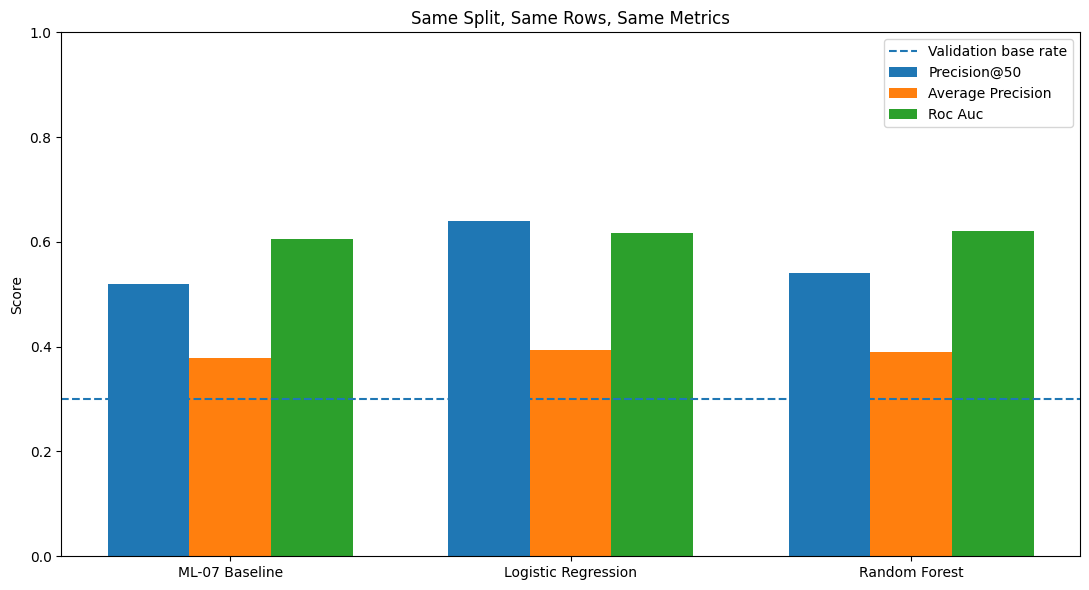

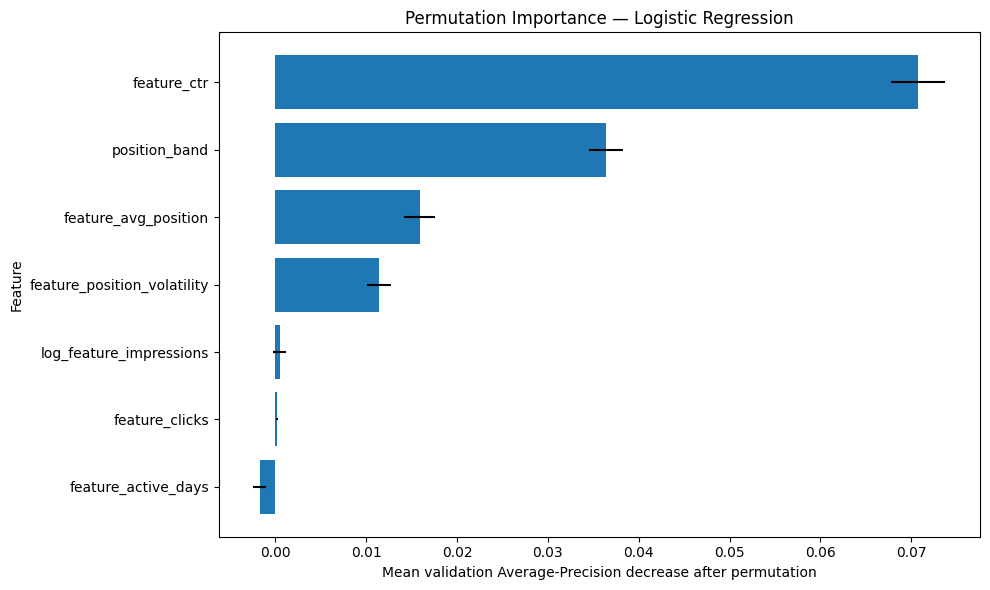

Saved selected model: work/outputs/capstone/models/capstone_selected_model.joblib


In [7]:
# ============================================================
# ERROR RECEIPT
# ============================================================

selected_predictions = (
    np.asarray(selected_scores, dtype=float)
    >=
    CLASSIFICATION_THRESHOLD
).astype(int)

confusion = confusion_matrix(
    validation_labels,
    selected_predictions,
    labels=[0, 1],
)

tn, fp, fn, tp = confusion.ravel()

threshold_accuracy = float(
    accuracy_score(
        validation_labels,
        selected_predictions,
    )
)

majority_accuracy = float(
    max(
        validation_base_rate,
        1.0 - validation_base_rate,
    )
)

top_50_indices = np.argsort(
    -np.asarray(selected_scores),
    kind="mergesort",
)[:TOP_K]

top_50_positive_count = int(
    validation_labels[top_50_indices].sum()
)

top_50_negative_count = int(
    TOP_K - top_50_positive_count
)

error_receipt = pd.DataFrame(
    [
        {
            "threshold": (
                CLASSIFICATION_THRESHOLD
            ),
            "true_negatives": int(tn),
            "false_positives": int(fp),
            "false_negatives": int(fn),
            "true_positives": int(tp),
            "threshold_accuracy": (
                threshold_accuracy
            ),
            "majority_accuracy": (
                majority_accuracy
            ),
            "top_50_proxy_positives": (
                top_50_positive_count
            ),
            "top_50_proxy_negatives": (
                top_50_negative_count
            ),
        }
    ]
)

display(error_receipt.round(4))


# ============================================================
# PERMUTATION IMPORTANCE
# ============================================================

permutation_result = permutation_importance(
    selected_model,
    validation_frame[feature_columns],
    validation_frame[target_column],
    scoring="average_precision",
    n_repeats=10,
    random_state=SEED,
    n_jobs=-1,
)

importance_table = pd.DataFrame(
    {
        "feature": feature_columns,
        "importance_mean": (
            permutation_result.importances_mean
        ),
        "importance_std": (
            permutation_result.importances_std
        ),
    }
)

importance_table["stable_positive"] = (
    importance_table["importance_mean"]
    -
    2
    * importance_table["importance_std"]
    >
    0
)

importance_table = (
    importance_table
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(importance_table.round(5))


# ============================================================
# FIGURES
# ============================================================

figure_paths = []

plot_methods = [
    "ML-07 Baseline",
    "Logistic Regression",
    "Random Forest",
]

plot_table = (
    comparison_table
    .set_index("method")
    .loc[plot_methods]
)

x_positions = np.arange(len(plot_methods))
bar_width = 0.24

plt.figure(figsize=(11, 6))

for index, metric in enumerate(
    [
        "precision@50",
        "average_precision",
        "roc_auc",
    ]
):
    plt.bar(
        x_positions
        + (index - 1) * bar_width,
        plot_table[metric].values,
        width=bar_width,
        label=metric.replace(
            "_",
            " ",
        ).title(),
    )

plt.axhline(
    validation_base_rate,
    linestyle="--",
    linewidth=1.5,
    label="Validation base rate",
)

plt.xticks(x_positions, plot_methods)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Same Split, Same Rows, Same Metrics")
plt.legend()
plt.tight_layout()

model_comparison_figure = (
    FIGURE_DIR
    / "capstone_model_vs_baseline.png"
)

plt.savefig(
    model_comparison_figure,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

figure_paths.append(model_comparison_figure)

plot_importance = importance_table.sort_values(
    "importance_mean",
    ascending=True,
)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_importance["feature"],
    plot_importance["importance_mean"],
    xerr=plot_importance["importance_std"],
)
plt.xlabel(
    "Mean validation Average-Precision decrease "
    "after permutation"
)
plt.ylabel("Feature")
plt.title(
    f"Permutation Importance — {selected_model_name}"
)
plt.tight_layout()

importance_figure = (
    FIGURE_DIR
    / "capstone_grouped_permutation_importance.png"
)

plt.savefig(
    importance_figure,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

figure_paths.append(importance_figure)

importance_table.to_csv(
    OUTPUT_DIR / "capstone_permutation_importance.csv",
    index=False,
)

error_receipt.to_csv(
    OUTPUT_DIR / "capstone_error_receipt.csv",
    index=False,
)

MODEL_PATH = (
    MODEL_DIR / "capstone_selected_model.joblib"
)

joblib.dump(selected_model, MODEL_PATH)

print("Saved selected model:", MODEL_PATH)

## 5. Limitations and Honest Framing

The target is an observational impression-decline proxy. The result comes from one month and one grouped holdout. The model does not observe query-level intent, SERP composition, competitors, technical failures, factual accuracy, editorial quality, conversion value, or business constraints. No content intervention was tested, and review time is a planning assumption rather than measured cost or ROI.

Permutation importance describes measured model reliance, not causal effects. Position band is derived from average position, so their individual importances are related.

The model supports review prioritisation only. It cannot support automatic publishing, deletion, redirect, canonical, no-index, metadata, causal, revenue, or guaranteed-recovery decisions.

In [8]:
limitations = pd.DataFrame(
    [
        {
            "limitation": "Observational proxy label",
            "cannot_claim": (
                "The model identifies true causal "
                "content decay."
            ),
            "safe_framing": (
                "The model ranks pages associated "
                "with a later impression-decline proxy."
            ),
        },
        {
            "limitation": (
                "One grouped holdout and one month"
            ),
            "cannot_claim": (
                "The result generalises unchanged "
                "to every future context."
            ),
            "safe_framing": (
                "The numbers are measured on the "
                "retained March 2026 holdout."
            ),
        },
        {
            "limitation": (
                "Incomplete explanatory view"
            ),
            "cannot_claim": (
                "The features fully explain why "
                "a page changed."
            ),
            "safe_framing": (
                "The score is one input to a wider "
                "page-level investigation."
            ),
        },
        {
            "limitation": (
                "No intervention experiment"
            ),
            "cannot_claim": (
                "The suggested action will recover "
                "traffic."
            ),
            "safe_framing": (
                "Actions indicate review priority, "
                "not treatment effect."
            ),
        },
        {
            "limitation": "No monetary outcome",
            "cannot_claim": (
                "The queue estimates revenue, profit, "
                "or monetary ROI."
            ),
            "safe_framing": (
                "Visibility and review time are "
                "planning proxies."
            ),
        },
        {
            "limitation": (
                "Weak diagnostic threshold result"
            ),
            "cannot_claim": (
                "The model is a reliable automatic "
                "binary decision engine."
            ),
            "safe_framing": (
                "The useful measured output is the "
                "ranked top-50 review queue."
            ),
        },
    ]
)

display(limitations)

limitations.to_csv(
    OUTPUT_DIR / "capstone_limitations.csv",
    index=False,
)

SAFE_CLAIM = (
    "On one grouped-client holdout, Logistic Regression "
    f"measured a Precision@50 of {model_precision_50:.3f}, "
    f"compared with {baseline_precision_50:.3f} for the "
    "frozen ML-07 baseline, an absolute measured difference "
    f"of {model_minus_baseline:.3f}. This observed result "
    "supports directional human decision-support for content-"
    "review prioritisation within the March 2026 evaluation "
    "design. It does not establish causal refresh impact, "
    "guarantee future performance, or support automatic "
    "content changes."
)

print(SAFE_CLAIM)

,limitation,cannot_claim,safe_framing
0,Observational proxy label,The model identifies true causal content decay.,The model ranks pages associated with a later ...
1,One grouped holdout and one month,The result generalises unchanged to every futu...,The numbers are measured on the retained March...
2,Incomplete explanatory view,The features fully explain why a page changed.,The score is one input to a wider page-level i...
3,No intervention experiment,The suggested action will recover traffic.,"Actions indicate review priority, not treatmen..."
4,No monetary outcome,"The queue estimates revenue, profit, or moneta...",Visibility and review time are planning proxies.
5,Weak diagnostic threshold result,The model is a reliable automatic binary decis...,The useful measured output is the ranked top-5...


On one grouped-client holdout, Logistic Regression measured a Precision@50 of 0.640, compared with 0.520 for the frozen ML-07 baseline, an absolute measured difference of 0.120. This observed result supports directional human decision-support for content-review prioritisation within the March 2026 evaluation design. It does not establish causal refresh impact, guarantee future performance, or support automatic content changes.


## 6. Ranked Recommendations

The selected model score is converted into transparent human-review archetypes: CTR Review, Expand and Optimise, Refresh Review, Refresh and Protect, Protect, Monitor, Manual Review, and No Immediate Action.

The priority heuristic combines 65% model score, 25% visibility percentile, and 10% feature-window data quality. It is a review-order heuristic, not a predicted financial return.

All action thresholds and reference distributions are calculated from training rows only. Later outcomes are used only for retrospective aggregate auditing. Every suggested action requires page-level human verification.

In [9]:
# ============================================================
# TRAINING-ONLY ACTION REFERENCES
# ============================================================

train_policy = train_frame.copy()
action_frame = validation_frame.copy()

train_policy["position_band_text"] = (
    train_policy["position_band"].astype(str)
)

action_frame["position_band_text"] = (
    action_frame["position_band"].astype(str)
)

training_position_ctr_medians = (
    train_policy
    .groupby(
        "position_band_text",
        observed=True,
    )["feature_ctr"]
    .median()
    .to_dict()
)

training_global_ctr = float(
    train_policy["feature_ctr"].median()
)

training_impression_q75 = float(
    train_policy["feature_impressions"]
    .quantile(0.75)
)

training_volatility_median = float(
    train_policy[
        "feature_position_volatility"
    ].median()
)

if not np.isfinite(training_volatility_median):
    training_volatility_median = 0.0

training_volatility_q75 = float(
    train_policy[
        "feature_position_volatility"
    ]
    .fillna(training_volatility_median)
    .quantile(0.75)
)

action_frame["model_score"] = np.asarray(
    selected_scores,
    dtype=float,
)

action_frame["policy_volatility"] = (
    action_frame[
        "feature_position_volatility"
    ].fillna(training_volatility_median)
)

action_frame[
    "position_band_ctr_reference"
] = (
    action_frame["position_band_text"]
    .map(training_position_ctr_medians)
    .astype(float)
    .fillna(training_global_ctr)
)

action_frame["visibility_value_proxy"] = (
    percentile_from_training(
        train_policy["feature_impressions"],
        action_frame["feature_impressions"],
    )
)

action_frame["data_quality_proxy"] = (
    (
        action_frame[
            "feature_active_days"
        ].clip(0, 15)
        / 15.0
    )
    +
    (
        action_frame[
            "feature_available_days"
        ].clip(0, 15)
        / 15.0
    )
) / 2.0

action_frame["review_priority_score"] = (
    100.0
    * (
        MODEL_SCORE_WEIGHT
        * action_frame["model_score"]
        +
        VISIBILITY_VALUE_WEIGHT
        * action_frame[
            "visibility_value_proxy"
        ]
        +
        DATA_QUALITY_WEIGHT
        * action_frame[
            "data_quality_proxy"
        ]
    )
).round(2)


def classify_action(
    row: pd.Series,
) -> pd.Series:
    score = float(row["model_score"])
    impressions = float(
        row["feature_impressions"]
    )
    ctr = float(row["feature_ctr"])
    position = float(
        row["feature_avg_position"]
    )
    volatility = float(
        row["policy_volatility"]
    )
    ctr_reference = float(
        row[
            "position_band_ctr_reference"
        ]
    )
    active_days = int(
        row["feature_active_days"]
    )
    available_days = int(
        row["feature_available_days"]
    )

    limited_evidence = (
        active_days < MIN_ACTION_ACTIVE_DAYS
        or
        available_days < MIN_ACTION_AVAILABLE_DAYS
    )

    high_visibility = (
        impressions >= training_impression_q75
    )

    weak_ctr = ctr < ctr_reference

    high_volatility = (
        volatility >= training_volatility_q75
    )

    stable_volatility = (
        volatility <= training_volatility_median
    )

    if limited_evidence and score >= BORDERLINE_LOW:
        return pd.Series(
            {
                "archetype": "LIMITED_EVIDENCE",
                "action_label": "MONITOR",
                "reason_code": (
                    "LIMITED_FEATURE_HISTORY"
                ),
                "confidence_level": "LOW",
                "confidence_note": (
                    "Collect more feature-window evidence."
                ),
            }
        )

    if (
        score >= HIGH_RISK_THRESHOLD
        and position <= 10
        and high_visibility
        and weak_ctr
    ):
        return pd.Series(
            {
                "archetype": (
                    "HIGH_VISIBILITY_WEAK_CTR"
                ),
                "action_label": "CTR_REVIEW",
                "reason_code": (
                    "CTR_GAP_HIGH_VISIBILITY"
                ),
                "confidence_level": "HIGH",
                "confidence_note": (
                    "High risk, strong visibility, and "
                    "CTR below the training reference."
                ),
            }
        )

    if (
        score >= HIGH_RISK_THRESHOLD
        and 10 < position <= 20
        and high_visibility
    ):
        return pd.Series(
            {
                "archetype": (
                    "VALUABLE_PAGE_2_OPPORTUNITY"
                ),
                "action_label": (
                    "EXPAND_AND_OPTIMISE"
                ),
                "reason_code": "HIGH_VALUE_PAGE_2",
                "confidence_level": "MEDIUM",
                "confidence_note": (
                    "High measured risk with strong "
                    "Page-2 visibility."
                ),
            }
        )

    if (
        score >= HIGH_RISK_THRESHOLD
        and high_volatility
    ):
        return pd.Series(
            {
                "archetype": "HIGH_RISK_VOLATILE",
                "action_label": "REFRESH_REVIEW",
                "reason_code": (
                    "HIGH_RISK_HIGH_VOLATILITY"
                ),
                "confidence_level": "MEDIUM",
                "confidence_note": (
                    "High measured risk with high "
                    "training-referenced volatility."
                ),
            }
        )

    if (
        score >= HIGH_RISK_THRESHOLD
        and position <= 10
        and stable_volatility
    ):
        return pd.Series(
            {
                "archetype": (
                    "HIGH_RISK_STABLE_VISIBILITY"
                ),
                "action_label": (
                    "REFRESH_AND_PROTECT"
                ),
                "reason_code": (
                    "HIGH_RISK_STABLE_PAGE_1"
                ),
                "confidence_level": "MEDIUM",
                "confidence_note": (
                    "High measured risk with stable "
                    "Page-1 visibility."
                ),
            }
        )

    if (
        score <= LOW_RISK_THRESHOLD
        and position <= 10
        and high_visibility
    ):
        return pd.Series(
            {
                "archetype": "LOW_RISK_HIGH_VALUE",
                "action_label": "PROTECT",
                "reason_code": (
                    "LOW_RISK_HIGH_VISIBILITY"
                ),
                "confidence_level": "MEDIUM",
                "confidence_note": (
                    "Low measured risk with strong "
                    "visibility."
                ),
            }
        )

    if BORDERLINE_LOW <= score < BORDERLINE_HIGH:
        return pd.Series(
            {
                "archetype": "BORDERLINE_RISK",
                "action_label": "MONITOR",
                "reason_code": (
                    "BORDERLINE_MEASURED_RISK"
                ),
                "confidence_level": "LOW",
                "confidence_note": (
                    "Collect more evidence before action."
                ),
            }
        )

    if score >= HIGH_RISK_THRESHOLD:
        return pd.Series(
            {
                "archetype": "HIGH_RISK_OTHER",
                "action_label": "MANUAL_REVIEW",
                "reason_code": (
                    "HIGH_RISK_NO_CLEAR_ARCHETYPE"
                ),
                "confidence_level": "LOW",
                "confidence_note": (
                    "A full human investigation is required."
                ),
            }
        )

    return pd.Series(
        {
            "archetype": "LOWER_PRIORITY_OTHER",
            "action_label": "NO_IMMEDIATE_ACTION",
            "reason_code": "LOWER_MEASURED_PRIORITY",
            "confidence_level": "LOW",
            "confidence_note": (
                "The page remains in monitoring."
            ),
        }
    )


action_frame[
    [
        "archetype",
        "action_label",
        "reason_code",
        "confidence_level",
        "confidence_note",
    ]
] = action_frame.apply(
    classify_action,
    axis=1,
)


# ============================================================
# COST, RANKING, AND SUMMARIES
# ============================================================

action_cost_map = {
    "CTR_REVIEW": ("LOW", 20),
    "EXPAND_AND_OPTIMISE": ("HIGH", 120),
    "REFRESH_REVIEW": ("MEDIUM", 90),
    "REFRESH_AND_PROTECT": ("MEDIUM", 75),
    "PROTECT": ("LOW", 15),
    "MONITOR": ("LOW", 10),
    "MANUAL_REVIEW": ("MEDIUM", 30),
    "NO_IMMEDIATE_ACTION": ("NONE", 0),
}

action_frame["review_cost_tier"] = (
    action_frame["action_label"].map(
        lambda action: action_cost_map[action][0]
    )
)

action_frame["estimated_review_minutes"] = (
    action_frame["action_label"].map(
        lambda action: action_cost_map[action][1]
    )
)

action_frame["human_review_required"] = (
    action_frame["action_label"]
    .ne("NO_IMMEDIATE_ACTION")
)

full_queue = (
    action_frame
    .sort_values(
        [
            "review_priority_score",
            "model_score",
            "feature_impressions",
        ],
        ascending=[False, False, False],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

full_queue.insert(
    0,
    "rank",
    np.arange(1, len(full_queue) + 1),
)

actionable_queue = (
    full_queue[
        full_queue["human_review_required"]
    ]
    .copy()
    .reset_index(drop=True)
)

actionable_queue.insert(
    0,
    "actionable_rank",
    np.arange(
        1,
        len(actionable_queue) + 1,
    ),
)

action_summary = (
    full_queue
    .groupby(
        ["action_label", "reason_code"],
        observed=True,
    )
    .agg(
        pages=(target_column, "size"),
        observed_decline_rate=(
            target_column,
            "mean",
        ),
        median_priority=(
            "review_priority_score",
            "median",
        ),
        median_model_score=(
            "model_score",
            "median",
        ),
        total_review_minutes=(
            "estimated_review_minutes",
            "sum",
        ),
    )
    .reset_index()
)

action_summary[
    "observed_decline_rate_pct"
] = (
    100.0
    * action_summary["observed_decline_rate"]
)

action_summary["estimated_review_hours"] = (
    action_summary["total_review_minutes"]
    / 60.0
)

action_summary["claim_status"] = np.where(
    action_summary["pages"]
    >=
    MIN_HEADLINE_GROUP_N,
    "DESCRIPTIVE_WITH_N",
    "INSUFFICIENT_N_FOR_HEADLINE",
)

action_summary = (
    action_summary
    .sort_values(
        ["observed_decline_rate", "pages"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

display(action_summary.round(4))


# ============================================================
# REVIEW RULES, NO-GO RULES, AND MONITORING
# ============================================================

human_review_rules = [
    "Confirm current search intent and SERP format.",
    "Inspect relevant query-level evidence.",
    "Rule out indexing, canonical, redirect, rendering, and tracking issues.",
    "Verify whether content is actually stale, inaccurate, or incomplete.",
    "Check CTR in the context of position, volume, and SERP features.",
    "Check brand, conversion, legal, compliance, and business role.",
    "Check cannibalisation and internal-link relationships.",
    "Assess the risk of damaging existing visibility.",
    "Choose the final action only after page-level inspection.",
    "Define an owner, measurement window, and rollback plan.",
]

no_go_list = [
    "Automatic publishing or rewriting.",
    "Automatic deletion, redirect, canonical, or no-index decisions.",
    "Automatic title, description, heading, or structured-data changes.",
    "Causal claims from observational associations.",
    "Exposure of client names, raw URLs, domains, or private queries.",
    "Override of editorial, legal, brand, safety, or compliance review.",
    "Action when data-quality or eligibility checks fail.",
    "Treatment of a model score as a final editorial decision.",
]

monitoring_triggers = pd.DataFrame(
    [
        {
            "trigger": (
                "Grouped Precision@50 drops by more than 0.10"
            ),
            "response": (
                "Pause broad use and repeat grouped validation."
            ),
        },
        {
            "trigger": (
                "Precision@50 approaches the base rate"
            ),
            "response": (
                "Stop claiming useful prioritisation."
            ),
        },
        {
            "trigger": (
                "Eligible population changes by more than 30%"
            ),
            "response": (
                "Audit filters, access flags, and client mix."
            ),
        },
        {
            "trigger": (
                "Feature missingness rises by more than five points"
            ),
            "response": (
                "Investigate data collection and preprocessing."
            ),
        },
        {
            "trigger": (
                "Mean model score changes by more than 0.10"
            ),
            "response": (
                "Audit drift and calibration."
            ),
        },
        {
            "trigger": (
                "Action mix shifts by more than 20 points"
            ),
            "response": (
                "Review thresholds and input drift."
            ),
        },
        {
            "trigger": (
                "New client, market, language, or content context"
            ),
            "response": (
                "Validate before operational use."
            ),
        },
        {
            "trigger": (
                "Full validation audit is older than 90 days"
            ),
            "response": (
                "Schedule grouped revalidation."
            ),
        },
    ]
)

QUEUE_PATH = (
    OUTPUT_DIR
    / "capstone_ranked_action_queue.csv"
)

ACTION_SUMMARY_PATH = (
    OUTPUT_DIR
    / "capstone_action_summary.csv"
)

queue_export_columns = [
    "rank",
    "client_hash_id",
    "content_hash_id",
    "review_priority_score",
    "model_score",
    "action_label",
    "reason_code",
    "archetype",
    "confidence_level",
    "review_cost_tier",
    "estimated_review_minutes",
    "human_review_required",
    "feature_impressions",
    "feature_clicks",
    "feature_ctr",
    "feature_avg_position",
    "feature_active_days",
    "feature_available_days",
    "policy_volatility",
    "position_band_text",
    "confidence_note",
]

full_queue[
    queue_export_columns
].to_csv(
    QUEUE_PATH,
    index=False,
)

action_summary.to_csv(
    ACTION_SUMMARY_PATH,
    index=False,
)

monitoring_triggers.to_csv(
    OUTPUT_DIR / "capstone_monitoring_triggers.csv",
    index=False,
)

print("Full queue rows:", f"{len(full_queue):,}")
print(
    "Actionable queue rows:",
    f"{len(actionable_queue):,}",
)

,action_label,reason_code,pages,observed_decline_rate,median_priority,median_model_score,total_review_minutes,observed_decline_rate_pct,estimated_review_hours,claim_status
0,MONITOR,LIMITED_FEATURE_HISTORY,26,0.6538,46.640,0.5163,260,65.3846,4.3333,INSUFFICIENT_N_FOR_HEADLINE
1,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,147,0.5306,70.850,0.6120,2940,53.0612,49.0000,DESCRIPTIVE_WITH_N
2,REFRESH_REVIEW,HIGH_RISK_HIGH_VOLATILITY,706,0.4448,58.225,0.6493,63540,44.4759,1059.0000,DESCRIPTIVE_WITH_N
3,REFRESH_AND_PROTECT,HIGH_RISK_STABLE_PAGE_1,546,0.4286,58.545,0.6137,40950,42.8571,682.5000,DESCRIPTIVE_WITH_N
4,MANUAL_REVIEW,HIGH_RISK_NO_CLEAR_ARCHETYPE,934,0.4176,58.400,0.6261,28020,41.7559,467.0000,DESCRIPTIVE_WITH_N
5,MONITOR,BORDERLINE_MEASURED_RISK,8412,0.3214,58.725,0.5310,84120,32.1446,1402.0000,DESCRIPTIVE_WITH_N
6,NO_IMMEDIATE_ACTION,LOWER_MEASURED_PRIORITY,4809,0.2152,46.860,0.3809,0,21.5221,0.0000,DESCRIPTIVE_WITH_N
7,PROTECT,LOW_RISK_HIGH_VISIBILITY,382,0.0759,50.470,0.2844,5730,7.5916,95.5000,DESCRIPTIVE_WITH_N
8,EXPAND_AND_OPTIMISE,HIGH_VALUE_PAGE_2,1,0.0000,71.460,0.6251,120,0.0000,2.0000,INSUFFICIENT_N_FOR_HEADLINE


Full queue rows: 15,963
Actionable queue rows: 11,154


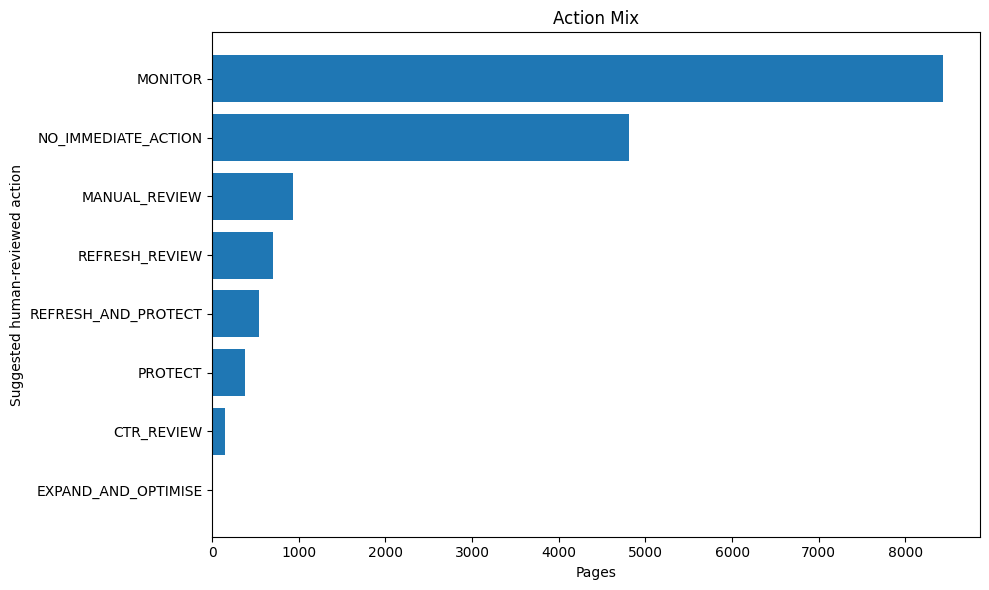

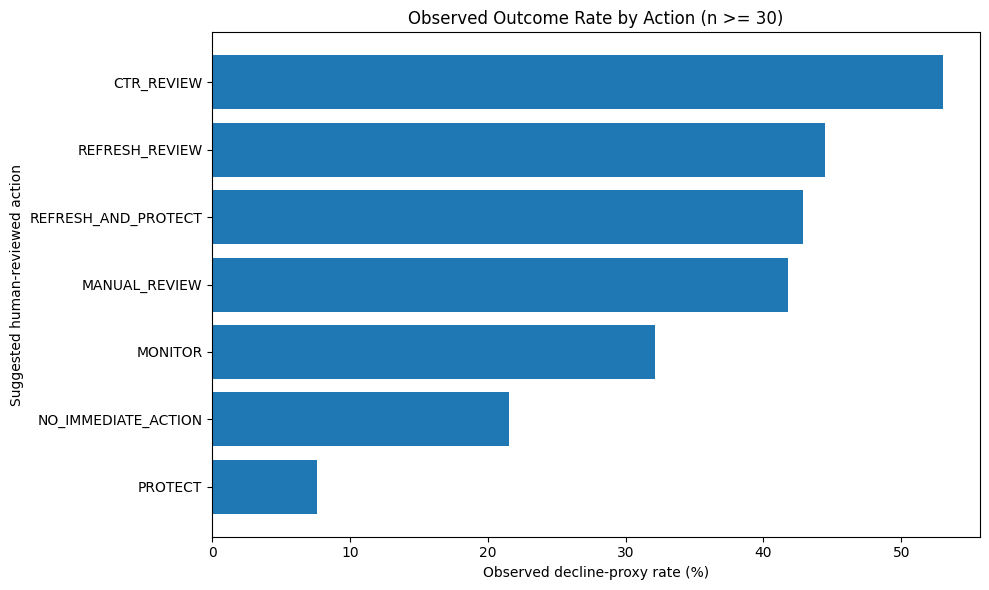

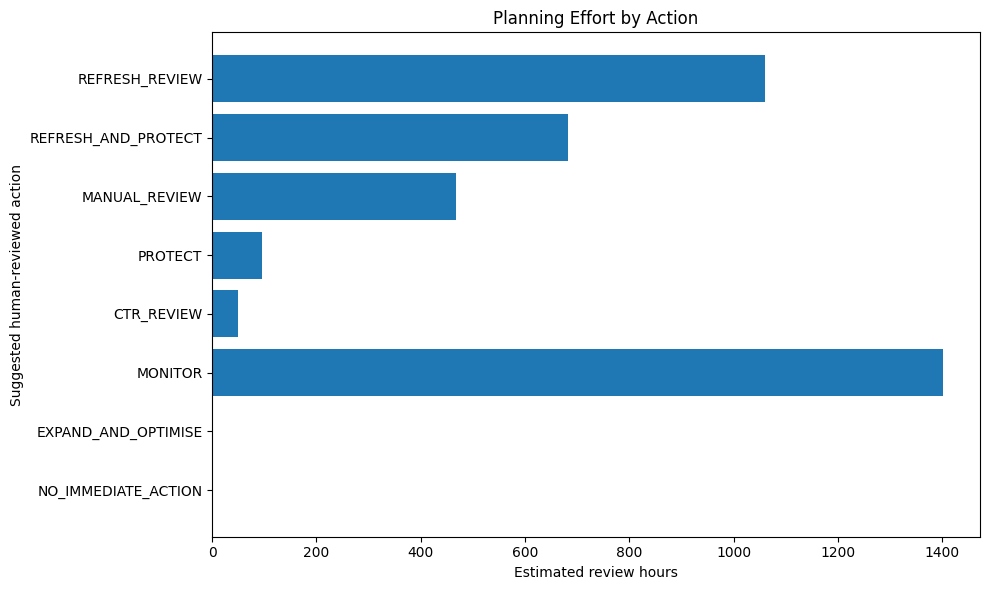

In [10]:
# ============================================================
# RECOMMENDATION FIGURES
# ============================================================

action_counts = (
    full_queue["action_label"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(action_counts.index, action_counts.values)
plt.xlabel("Pages")
plt.ylabel("Suggested human-reviewed action")
plt.title("Action Mix")
plt.tight_layout()

action_mix_figure = (
    FIGURE_DIR / "capstone_action_mix.png"
)

plt.savefig(
    action_mix_figure,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

figure_paths.append(action_mix_figure)

decline_figure_data = (
    action_summary[
        action_summary["pages"]
        >=
        MIN_HEADLINE_GROUP_N
    ]
    .copy()
    .sort_values(
        "observed_decline_rate_pct",
        ascending=True,
    )
)

plt.figure(figsize=(10, 6))
plt.barh(
    decline_figure_data["action_label"],
    decline_figure_data[
        "observed_decline_rate_pct"
    ],
)
plt.xlabel("Observed decline-proxy rate (%)")
plt.ylabel("Suggested human-reviewed action")
plt.title(
    "Observed Outcome Rate by Action "
    f"(n >= {MIN_HEADLINE_GROUP_N})"
)
plt.tight_layout()

decline_by_action_figure = (
    FIGURE_DIR
    / "capstone_observed_decline_by_action.png"
)

plt.savefig(
    decline_by_action_figure,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

figure_paths.append(
    decline_by_action_figure
)

review_hours_data = (
    action_summary
    .sort_values(
        "estimated_review_hours",
        ascending=True,
    )
)

plt.figure(figsize=(10, 6))
plt.barh(
    review_hours_data["action_label"],
    review_hours_data[
        "estimated_review_hours"
    ],
)
plt.xlabel("Estimated review hours")
plt.ylabel("Suggested human-reviewed action")
plt.title("Planning Effort by Action")
plt.tight_layout()

review_hours_figure = (
    FIGURE_DIR
    / "capstone_review_hours_by_action.png"
)

plt.savefig(
    review_hours_figure,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

figure_paths.append(review_hours_figure)

## 7. Publication Artifacts, Reproducibility, and Data Credit

The notebook generates:

- the responsive research page at `docs/index.html`;
- the searchable technical-report PDF at `docs/paper.pdf`;
- a verified literature page at `docs/literature.html`;
- Google Scholar Highwire metadata and JSON-LD;
- `CITATION.cff`;
- `docs/sitemap.xml` and `docs/robots.txt`;
- `work/capstone_report.md`;
- aggregate model, validation, leakage, action, and publication receipts;
- five paper figures and the selected fitted pipeline;
- the exact GitHub Pages URL in `submission/paper_url.txt`.

Anyone with approved dataset access can rerun the weekly notebooks and the capstone. The seed is 42, the grouped holdout size is 25%, and raw warehouse data are not redistributed.

Built on the [FlyRank ML Internship dataset](https://flyrank.ai).


## Publication Asset and Scholarly Metadata

This section is self-contained.

The notebook embeds the corrected Version 1.2 searchable PDF and writes
it to `docs/paper.pdf` whenever the repository copy is missing,
outdated, or contains the old university name.

Required affiliation:

**Department of Computer Science, University of Engineering & Technology Mardan, Pakistan**

The validation normalises PDF-extracted whitespace and confirms that
the old affiliation is absent.


In [11]:
# ============================================================
# SELF-CONTAINED PUBLICATION PDF RESOLUTION
# ============================================================

import base64
import re

CORRECTED_PDF_FILENAME = (
    "ML11_Research_Paper_Zafar_Ullah_v1_2.pdf"
)

CORRECTED_PDF_BASE64 = """..."""


def normalise_publication_text(value: str) -> str:
    value = value.replace("\u00a0", " ")
    value = value.replace("\u2013", "-")
    value = value.replace("\u2014", "-")
    return re.sub(r"\s+", " ", value).strip()


def extract_pdf_searchable_text(
    pdf_path: Path,
) -> tuple[PdfReader, str]:
    reader = PdfReader(str(pdf_path))

    if reader.is_encrypted:
        raise ValueError(
            "The publication PDF must not be encrypted."
        )

    extracted_text = "\n".join(
        page.extract_text() or ""
        for page in reader.pages
    )

    return (
        reader,
        normalise_publication_text(
            extracted_text
        ),
    )


def pdf_has_correct_affiliation(
    pdf_path: Path,
) -> bool:
    if not pdf_path.exists():
        return False

    try:
        _, searchable_text = (
            extract_pdf_searchable_text(
                pdf_path
            )
        )
    except Exception:
        return False

    return (
        normalise_publication_text(
            AUTHOR_AFFILIATION
        )
        in searchable_text
        and
        normalise_publication_text(
            OLD_AUTHOR_AFFILIATION
        )
        not in searchable_text
    )


embedded_pdf_path = (
    Path("/content")
    / CORRECTED_PDF_FILENAME
)

embedded_pdf_path.write_bytes(
    base64.b64decode(
        CORRECTED_PDF_BASE64.encode("ascii")
    )
)

if not embedded_pdf_path.read_bytes().startswith(
    b"%PDF"
):
    raise ValueError(
        "The embedded publication artifact is not a valid PDF."
    )

if not pdf_has_correct_affiliation(
    PAPER_PDF_PATH
):
    shutil.copy2(
        embedded_pdf_path,
        PAPER_PDF_PATH,
    )
    print(
        "Replaced docs/paper.pdf with the corrected "
        "Version 1.2 PDF."
    )
else:
    print(
        "docs/paper.pdf already contains the correct "
        "Version 1.2 affiliation."
    )


# ============================================================
# FINAL PDF VALIDATION
# ============================================================

paper_bytes = PAPER_PDF_PATH.read_bytes()

if not paper_bytes.startswith(b"%PDF"):
    raise ValueError(
        "docs/paper.pdf is not a valid PDF file."
    )

paper_sha256 = hashlib.sha256(
    paper_bytes
).hexdigest()

paper_reader, paper_searchable_text = (
    extract_pdf_searchable_text(
        PAPER_PDF_PATH
    )
)

paper_page_count = len(
    paper_reader.pages
)

paper_pdf_metadata = {
    str(key): str(value)
    for key, value in (
        paper_reader.metadata or {}
    ).items()
}

if paper_page_count < 10:
    raise ValueError(
        "The publication PDF has fewer pages than expected."
    )

normalised_correct_affiliation = (
    normalise_publication_text(
        AUTHOR_AFFILIATION
    )
)

normalised_old_affiliation = (
    normalise_publication_text(
        OLD_AUTHOR_AFFILIATION
    )
)

if (
    normalised_correct_affiliation
    not in paper_searchable_text
):
    raise ValueError(
        "The corrected publication PDF does not contain "
        "the official UET Mardan affiliation."
    )

if (
    normalised_old_affiliation
    in paper_searchable_text
):
    raise ValueError(
        "The publication PDF still contains the old "
        "university affiliation."
    )

print("PDF affiliation verified:")
print(AUTHOR_AFFILIATION)
print("Old affiliation absent:", True)


# ============================================================
# SOFTWARE ENVIRONMENT
# ============================================================

def safe_package_version(
    package_name: str,
) -> str:
    try:
        return importlib_metadata.version(
            package_name
        )
    except importlib_metadata.PackageNotFoundError:
        return "not-installed"


software_environment = {
    "python": platform.python_version(),
    "execution_environment": (
        "Google Colab"
        if userdata is not None
        else platform.platform()
    ),
    "pandas": safe_package_version("pandas"),
    "numpy": safe_package_version("numpy"),
    "scikit-learn": safe_package_version(
        "scikit-learn"
    ),
    "matplotlib": safe_package_version(
        "matplotlib"
    ),
    "duckdb": safe_package_version("duckdb"),
    "huggingface_hub": safe_package_version(
        "huggingface-hub"
    ),
    "joblib": safe_package_version("joblib"),
    "pypdf": safe_package_version("pypdf"),
    "random_seed": SEED,
    "grouped_validation_fraction": TEST_SIZE,
}

software_environment_df = pd.DataFrame(
    [
        {
            "component": key,
            "version_or_setting": value,
        }
        for key, value in (
            software_environment.items()
        )
    ]
)

display(software_environment_df)


# ============================================================
# PUBLICATION RECEIPT
# ============================================================

publication_receipt = {
    "title": PAPER_TITLE,
    "short_title": PAPER_SHORT_TITLE,
    "author": AUTHOR_NAME,
    "affiliation": AUTHOR_AFFILIATION,
    "corresponding_email": AUTHOR_EMAIL,
    "orcid": (
        AUTHOR_ORCID
        if AUTHOR_ORCID
        else "Not available"
    ),
    "paper_type": PAPER_TYPE,
    "version": PAPER_VERSION,
    "publication_status": PUBLICATION_STATUS,
    "publication_date": PUBLICATION_DATE,
    "doi": (
        PAPER_DOI
        if PAPER_DOI
        else "To be assigned"
    ),
    "license": LICENSE_NAME,
    "license_url": LICENSE_URL,
    "paper_url": PAPER_URL,
    "pdf_url": PAPER_PDF_URL,
    "literature_url": LITERATURE_URL,
    "pdf_path": str(PAPER_PDF_PATH),
    "pdf_pages": paper_page_count,
    "pdf_bytes": len(paper_bytes),
    "pdf_sha256": paper_sha256,
    "pdf_encrypted": bool(
        paper_reader.is_encrypted
    ),
    "pdf_affiliation_verified": True,
    "old_affiliation_absent": True,
    "automatic_action": False,
    "causal_claim": False,
}

publication_receipt_df = pd.DataFrame(
    [publication_receipt]
)

display(publication_receipt_df.T)

with PUBLICATION_MANIFEST_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        {
            **publication_receipt,
            "software_environment": (
                software_environment
            ),
            "pdf_metadata": (
                paper_pdf_metadata
            ),
        },
        file,
        indent=2,
    )

print("Validated paper:", PAPER_PDF_PATH)
print("PDF pages:", paper_page_count)
print("PDF SHA-256:", paper_sha256)


Replaced docs/paper.pdf with the corrected Version 1.2 PDF.
PDF affiliation verified:
Department of Computer Science, University of Engineering & Technology Mardan, Pakistan
Old affiliation absent: True


,component,version_or_setting
0,python,3.12.13
1,execution_environment,Google Colab
2,pandas,2.2.2
3,numpy,2.0.2
4,scikit-learn,1.6.1
5,matplotlib,3.10.0
6,duckdb,1.3.2
7,huggingface_hub,1.23.0
8,joblib,1.5.3
9,pypdf,6.14.2


,0
title,Refresh and Content Opportunity Scoring Using ...
short_title,Refresh and Content Opportunity Scoring
author,Zafar Ullah
affiliation,"Department of Computer Science, University of ..."
corresponding_email,zafarullah1385@gmail.com
orcid,Not available
paper_type,Technical Report
version,1.2
publication_status,Pre-DOI
publication_date,2026-07-30


Validated paper: docs/paper.pdf
PDF pages: 16
PDF SHA-256: 590e4e3c06be662e2198598bd2d814066c51765438ab754dc6fb51c282e6a4f6


In [12]:
# ============================================================
# COPY RELATIVE ASSETS
# ============================================================

asset_mapping = {
    model_comparison_figure: (
        DOCS_ASSET_DIR / "model-vs-baseline.png"
    ),
    importance_figure: (
        DOCS_ASSET_DIR / "permutation-importance.png"
    ),
    action_mix_figure: (
        DOCS_ASSET_DIR / "action-mix.png"
    ),
    decline_by_action_figure: (
        DOCS_ASSET_DIR / "outcome-by-action.png"
    ),
    review_hours_figure: (
        DOCS_ASSET_DIR / "review-hours.png"
    ),
}

for source_path, destination_path in (
    asset_mapping.items()
):
    shutil.copy2(
        source_path,
        destination_path,
    )


# ============================================================
# PUBLIC-SAFE TABLES
# ============================================================

public_result_table = (
    comparison_table[
        [
            "method",
            "base_rate",
            "precision@20",
            "precision@50",
            "lift@50_vs_base_rate",
            "average_precision",
            "roc_auc",
        ]
    ]
    .copy()
    .round(4)
)

public_action_table = (
    action_summary[
        [
            "action_label",
            "reason_code",
            "pages",
            "observed_decline_rate_pct",
            "median_priority",
            "estimated_review_hours",
            "claim_status",
        ]
    ]
    .copy()
    .round(2)
)

public_importance_table = (
    importance_table[
        [
            "feature",
            "importance_mean",
            "importance_std",
            "stable_positive",
        ]
    ]
    .copy()
    .round(5)
)

public_validation_table = (
    validation_design_comparison[
        [
            "method",
            "validation_rows",
            "validation_clients",
            "client_overlap",
            "base_rate",
            "precision@50",
            "average_precision",
            "roc_auc",
        ]
    ]
    .copy()
    .round(4)
)

result_table_html = public_result_table.to_html(
    index=False,
    classes="research-table",
    border=0,
)

action_table_html = public_action_table.to_html(
    index=False,
    classes="research-table",
    border=0,
)

importance_table_html = (
    public_importance_table.to_html(
        index=False,
        classes="research-table",
        border=0,
    )
)

validation_table_html = (
    public_validation_table.to_html(
        index=False,
        classes="research-table",
        border=0,
    )
)


# ============================================================
# LIVE FIVE-SENTENCE ABSTRACT
# ============================================================

ABSTRACT_SENTENCES = [
    (
        "This study asks whether historical search-performance "
        "signals can prioritise eligible content pages for "
        "human review."
    ),
    (
        f"Using {int(data_receipt.loc[0, 'source_rows']):,} "
        "daily warehouse rows from March 2026, it creates "
        f"{len(model_frame):,} eligible anonymised client-page "
        "records from separated feature and outcome windows."
    ),
    (
        "A transparent ML-07 baseline, Logistic Regression, "
        "and Random Forest are evaluated on the same grouped-"
        "client holdout, while a deliberate future-field "
        "experiment audits leakage."
    ),
    (
        f"{selected_model_name} measured a Precision@50 of "
        f"{model_precision_50:.3f} compared with "
        f"{baseline_precision_50:.3f} for the frozen baseline, "
        f"while the validation base rate was "
        f"{validation_base_rate:.3f}."
    ),
    (
        "The observed result supports directional human "
        "decision-support and does not establish causal refresh "
        "impact, guaranteed recovery, or automatic editing."
    ),
]

assert len(ABSTRACT_SENTENCES) == 5

abstract_html = " ".join(
    html.escape(sentence)
    for sentence in ABSTRACT_SENTENCES
)


# ============================================================
# CSS
# ============================================================

css_text = """
:root {
  --ink: #172033;
  --muted: #5b6578;
  --paper: #ffffff;
  --canvas: #f3f6fb;
  --line: #d8dfeb;
  --brand: #173f7a;
  --brand-2: #2469b2;
  --accent: #e8f1fc;
  --shadow: 0 16px 42px rgba(23, 63, 122, 0.10);
}
* { box-sizing: border-box; }
html { scroll-behavior: smooth; }
body {
  margin: 0;
  color: var(--ink);
  background: var(--canvas);
  font-family: Inter, ui-sans-serif, system-ui, -apple-system,
    BlinkMacSystemFont, "Segoe UI", sans-serif;
  line-height: 1.7;
}
a { color: var(--brand-2); }
a:focus-visible {
  outline: 3px solid #ffbf47;
  outline-offset: 3px;
}
.skip-link { position: absolute; left: -9999px; }
.skip-link:focus {
  left: 1rem; top: 1rem; z-index: 1000;
  padding: 0.7rem 1rem; background: white; color: black;
}
.site-header {
  color: white;
  background: linear-gradient(135deg, #102d56, #173f7a 58%, #255e9c);
}
.header-inner, .page-shell {
  width: min(1160px, calc(100% - 2rem));
  margin: 0 auto;
}
.header-inner { padding: 4rem 0 3rem; }
.eyebrow {
  font-weight: 800; letter-spacing: 0.12em;
  text-transform: uppercase; opacity: 0.86;
}
h1 {
  max-width: 940px; margin: 0;
  font-size: clamp(2.2rem, 6vw, 4.4rem);
  line-height: 1.05; letter-spacing: -0.04em;
}
.subtitle { max-width: 820px; color: #dce9f8; }
.meta-row { display: flex; flex-wrap: wrap; gap: 0.7rem; }
.meta-chip {
  padding: 0.45rem 0.75rem;
  border: 1px solid rgba(255,255,255,0.3);
  border-radius: 999px;
  background: rgba(255,255,255,0.10);
}
.site-nav {
  position: sticky; top: 0; z-index: 10; overflow-x: auto;
  border-bottom: 1px solid var(--line);
  background: rgba(255,255,255,0.96);
}
.site-nav ul {
  width: min(1160px, calc(100% - 2rem));
  margin: 0 auto; padding: 0;
  display: flex; list-style: none;
}
.site-nav a {
  display: block; padding: 0.9rem 0.7rem;
  color: var(--ink); font-weight: 700;
  text-decoration: none; white-space: nowrap;
}
.site-nav a:hover { background: var(--accent); }
.page-shell { padding: 2rem 0 5rem; }
.paper-section {
  margin: 1.25rem 0;
  padding: clamp(1.25rem, 4vw, 2.5rem);
  border: 1px solid var(--line);
  border-radius: 1rem;
  background: var(--paper);
  box-shadow: var(--shadow);
}
.paper-section h2 { margin-top: 0; }
.abstract { font-size: 1.06rem; }
.metric-grid {
  display: grid;
  grid-template-columns: repeat(auto-fit, minmax(175px, 1fr));
  gap: 1rem; margin: 1.25rem 0;
}
.metric-card {
  padding: 1rem; border: 1px solid #c7d8ee;
  border-radius: 0.9rem; background: #f5f9ff;
}
.metric-value {
  display: block; font-size: 1.75rem;
  font-weight: 850; color: var(--brand);
}
.metric-label { color: var(--muted); font-size: 0.88rem; }
.callout {
  margin: 1.25rem 0; padding: 1rem 1.2rem;
  border-left: 5px solid var(--brand-2);
  background: var(--accent);
}
.callout.limit {
  border-left-color: #8b5e00; background: #fff7df;
}
.table-wrap {
  overflow-x: auto; margin: 1rem 0;
  border: 1px solid var(--line); border-radius: 0.8rem;
}
.research-table {
  width: 100%; border-collapse: collapse;
  min-width: 720px; font-size: 0.88rem;
}
.research-table th, .research-table td {
  padding: 0.75rem; border-bottom: 1px solid var(--line);
  text-align: left; vertical-align: top;
}
.research-table th { background: #eaf2fc; color: #173f7a; }
.research-table tbody tr:nth-child(even) { background: #fafcff; }
figure { margin: 1.6rem 0; }
figure img {
  width: 100%; height: auto; display: block;
  border: 1px solid var(--line); border-radius: 0.8rem;
}
figcaption { margin-top: 0.65rem; color: var(--muted); }
.two-column {
  display: grid;
  grid-template-columns: repeat(auto-fit, minmax(270px, 1fr));
  gap: 1.1rem;
}
.list-card {
  padding: 1rem 1.2rem;
  border: 1px solid var(--line);
  border-radius: 0.8rem; background: #fbfcfe;
}
.code-block {
  overflow-x: auto; padding: 1rem;
  background: #111827; color: #edf2f7;
  border-radius: 0.7rem; white-space: pre;
}
footer { padding: 2rem; color: var(--muted); text-align: center; }

.action-row {
  display: flex;
  flex-wrap: wrap;
  gap: 0.75rem;
  margin: 1.35rem 0;
}
.primary-button,
.secondary-button {
  display: inline-block;
  padding: 0.72rem 1rem;
  border-radius: 0.65rem;
  font-weight: 800;
  text-decoration: none;
}
.primary-button {
  color: white;
  background: var(--brand-2);
}
.secondary-button {
  color: var(--brand);
  border: 1px solid #aac4e5;
  background: white;
}
.reference-grid {
  display: grid;
  gap: 1rem;
  width: min(1160px, calc(100% - 2rem));
  margin: 1.25rem auto 4rem;
}
.reference-card {
  padding: 1.2rem;
  border: 1px solid var(--line);
  border-radius: 0.9rem;
  background: var(--paper);
  box-shadow: var(--shadow);
}
.reference-card h2 {
  margin-top: 0;
  font-size: 1.05rem;
}
.publication-grid {
  display: grid;
  grid-template-columns: repeat(
    auto-fit,
    minmax(220px, 1fr)
  );
  gap: 0.9rem;
}
.publication-item {
  padding: 0.9rem;
  border: 1px solid var(--line);
  border-radius: 0.75rem;
  background: #fbfcfe;
}

@media (max-width: 720px) {
  .site-nav ul { width: max-content; padding: 0 1rem; }
}
@media print {
  .site-nav, .skip-link { display: none; }
  body { background: white; }
  .paper-section { box-shadow: none; }
}
"""

(DOCS_ASSET_DIR / "style.css").write_text(
    css_text,
    encoding="utf-8",
)


# ============================================================
# HTML FRAGMENTS
# ============================================================

human_review_html = "".join(
    f"<li>{html.escape(item)}</li>"
    for item in human_review_rules
)

no_go_html = "".join(
    f"<li>{html.escape(item)}</li>"
    for item in no_go_list
)

limitations_html = "".join(
    (
        "<li><strong>"
        + html.escape(row["limitation"])
        + ":</strong> "
        + html.escape(row["safe_framing"])
        + "</li>"
    )
    for _, row in limitations.iterrows()
)

references_html = (
    "<ol>"
    + "".join(
        (
            "<li>"
            + html.escape(
                reference["citation"]
            )
            + " "
            + (
                '<a href="'
                + html.escape(
                    reference["url"],
                    quote=True,
                )
                + '" target="_blank" rel="noopener">'
                + html.escape(
                    reference["link_label"]
                )
                + "</a>."
            )
            + "</li>"
        )
        for reference in publication_references
    )
    + "</ol>"
)

notebook_links_html = """
<ul>
  <li><a href="https://github.com/Zafar488/flyrank-ml-internship/blob/main/work/notebooks/w03_data_contract.ipynb">Data contract</a></li>
  <li><a href="https://github.com/Zafar488/flyrank-ml-internship/blob/main/work/notebooks/w04_baseline_score.ipynb">Transparent baseline</a></li>
  <li><a href="https://github.com/Zafar488/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb">Capstone model</a></li>
  <li><a href="https://github.com/Zafar488/flyrank-ml-internship/blob/main/work/notebooks/w06_validation_audit.ipynb">Validation audit</a></li>
  <li><a href="https://github.com/Zafar488/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb">Action playbook</a></li>
  <li><a href="https://github.com/Zafar488/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb">Capstone notebook</a></li>
</ul>
"""


# ============================================================
# SCHOLARLY METADATA AND PUBLICATION FILES
# ============================================================

citation_keywords = [
    "search engine optimization",
    "content refresh",
    "content opportunity scoring",
    "grouped validation",
    "data leakage",
    "logistic regression",
    "decision support",
]

citation_doi_meta = (
    (
        '<meta name="citation_doi" content="'
        + html.escape(
            PAPER_DOI,
            quote=True,
        )
        + '">'
    )
    if PAPER_DOI
    else ""
)

scholarly_json_ld = json.dumps(
    {
        "@context": "https://schema.org",
        "@type": "ScholarlyArticle",
        "headline": PAPER_TITLE,
        "alternativeHeadline": PAPER_SHORT_TITLE,
        "author": {
            "@type": "Person",
            "name": AUTHOR_NAME,
            "email": AUTHOR_EMAIL,
            "affiliation": {
                "@type": "Organization",
                "name": AUTHOR_AFFILIATION,
            },
        },
        "datePublished": PUBLICATION_DATE,
        "dateModified": PUBLICATION_DATE,
        "version": PAPER_VERSION,
        "isAccessibleForFree": True,
        "license": LICENSE_URL,
        "url": PAPER_URL,
        "mainEntityOfPage": PAPER_URL,
        "encoding": {
            "@type": "MediaObject",
            "contentUrl": PAPER_PDF_URL,
            "encodingFormat": "application/pdf",
            "sha256": paper_sha256,
        },
        "keywords": citation_keywords,
        "abstract": " ".join(
            ABSTRACT_SENTENCES
        ),
        **(
            {"identifier": PAPER_DOI}
            if PAPER_DOI
            else {}
        ),
    },
    ensure_ascii=False,
)

citation_cff_text = f"""cff-version: 1.2.0
message: "If you use this work, please cite it using the metadata below."
title: "{PAPER_TITLE}"
type: report
authors:
  - family-names: "Ullah"
    given-names: "Zafar"
    affiliation: "{AUTHOR_AFFILIATION}"
    email: "{AUTHOR_EMAIL}"
version: "{PAPER_VERSION}"
date-released: "{PUBLICATION_DATE}"
url: "{PAPER_URL}"
repository-code: "{REPO_URL}"
license: "CC-BY-4.0"
abstract: >-
  {" ".join(ABSTRACT_SENTENCES)}
keywords:
"""
citation_cff_text += "".join(
    f'  - "{keyword}"\n'
    for keyword in citation_keywords
)

if PAPER_DOI:
    citation_cff_text += (
        f'doi: "{PAPER_DOI}"\n'
    )

CITATION_CFF_PATH.write_text(
    citation_cff_text,
    encoding="utf-8",
)

PUBLICATION_METADATA_PATH.write_text(
    json.dumps(
        {
            **publication_receipt,
            "keywords": citation_keywords,
            "abstract": " ".join(
                ABSTRACT_SENTENCES
            ),
            "software_environment": (
                software_environment
            ),
        },
        indent=2,
    ),
    encoding="utf-8",
)

SITEMAP_PATH.write_text(
    (
        '<?xml version="1.0" encoding="UTF-8"?>\n'
        '<urlset xmlns="http://www.sitemaps.org/'
        'schemas/sitemap/0.9">\n'
        f"  <url><loc>{PAPER_URL}</loc></url>\n"
        f"  <url><loc>{PAPER_PDF_URL}</loc></url>\n"
        f"  <url><loc>{LITERATURE_URL}</loc></url>\n"
        "</urlset>\n"
    ),
    encoding="utf-8",
)

ROBOTS_PATH.write_text(
    (
        "User-agent: *\n"
        "Allow: /\n"
        f"Sitemap: {PAPER_URL.rstrip('/')}/sitemap.xml\n"
    ),
    encoding="utf-8",
)

literature_items_html = "".join(
    (
        '<article class="reference-card">'
        "<h2>"
        + html.escape(
            reference["citation"]
        )
        + "</h2>"
        "<p>"
        + html.escape(
            reference["role"]
        )
        + "</p>"
        '<p><a href="'
        + html.escape(
            reference["url"],
            quote=True,
        )
        + '" target="_blank" rel="noopener">'
        + html.escape(
            reference["link_label"]
        )
        + "</a></p>"
        "</article>"
    )
    for reference in publication_references
)

literature_page = f"""<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <title>Verified Literature | {html.escape(PAPER_SHORT_TITLE)}</title>
  <meta name="description" content="Verified literature supporting the refresh and content opportunity scoring technical report.">
  <link rel="canonical" href="{LITERATURE_URL}">
  <link rel="stylesheet" href="assets/style.css">
</head>
<body>
  <main class="page-shell">
    <section class="paper-section">
      <p class="eyebrow">Verified Literature</p>
      <h1>{html.escape(PAPER_SHORT_TITLE)}</h1>
      <p>These sources support the methodology, interpretation, governance, and future-work sections of the technical report.</p>
      <p><a class="primary-button" href="index.html">Back to paper</a></p>
    </section>
    <section class="reference-grid">
      {literature_items_html}
    </section>
  </main>
</body>
</html>
"""

LITERATURE_PATH.write_text(
    literature_page,
    encoding="utf-8",
)


# ============================================================
# STATIC RESEARCH PAGE
# ============================================================

html_page = f"""<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <title>{html.escape(PAPER_TITLE)}</title>
  <meta name="description" content="A grouped-client machine-learning study of refresh and content opportunity scoring using organic search signals.">
  <link rel="canonical" href="{PAPER_URL}">
  <meta name="citation_title" content="{html.escape(PAPER_TITLE, quote=True)}">
  <meta name="citation_author" content="{html.escape(AUTHOR_NAME, quote=True)}">
  <meta name="citation_author_institution" content="{html.escape(AUTHOR_AFFILIATION, quote=True)}">
  <meta name="citation_author_email" content="{html.escape(AUTHOR_EMAIL, quote=True)}">
  <meta name="citation_publication_date" content="{PUBLICATION_DATE.replace('-', '/')}">
  <meta name="citation_pdf_url" content="{PAPER_PDF_URL}">
  <meta name="citation_technical_report_institution" content="{html.escape(AUTHOR_AFFILIATION, quote=True)}">
  <meta name="citation_technical_report_number" content="ML-11-v{PAPER_VERSION}">
  <meta name="citation_language" content="en">
  <meta name="citation_keywords" content="{html.escape(', '.join(citation_keywords), quote=True)}">
  <meta name="citation_abstract" content="{html.escape(' '.join(ABSTRACT_SENTENCES), quote=True)}">
  {citation_doi_meta}
  <meta property="og:title" content="{html.escape(PAPER_TITLE)}">
  <meta property="og:description" content="Logistic Regression measured Precision@50 of {model_precision_50:.3f} versus {baseline_precision_50:.3f} for a transparent baseline.">
  <meta property="og:type" content="article">
  <meta property="og:url" content="{PAPER_URL}">
  <meta property="og:image" content="{PAPER_URL.rstrip('/')}/assets/model-vs-baseline.png">
  <script type="application/ld+json">{scholarly_json_ld}</script>
  <link rel="stylesheet" href="assets/style.css">
</head>
<body>
  <a class="skip-link" href="#main-content">Skip to main content</a>

  <header class="site-header">
    <div class="header-inner">
      <p class="eyebrow">ML-11 | Refresh / Content Opportunity Scoring</p>
      <h1>{html.escape(PAPER_TITLE)}</h1>
      <p class="subtitle">A reproducible decision-support study built from separated windows, grouped-client validation, leakage auditing, and a human-reviewed action playbook.</p>
      <div class="meta-row">
        <span class="meta-chip">Author: {html.escape(AUTHOR_NAME)}</span>
        <span class="meta-chip">{html.escape(AUTHOR_AFFILIATION)}</span>
        <span class="meta-chip">{PAPER_TYPE} v{PAPER_VERSION}</span>
        <span class="meta-chip">{PUBLICATION_STATUS}</span>
        <span class="meta-chip">Precision@50</span>
        <span class="meta-chip">Human review required</span>
      </div>
      <div class="action-row">
        <a class="primary-button" href="paper.pdf">Download searchable PDF</a>
        <a class="secondary-button" href="literature.html">Verified literature</a>
        <a class="secondary-button" href="{REPO_URL}">View repository</a>
      </div>
    </div>
  </header>

  <nav class="site-nav" aria-label="Paper sections">
    <ul>
      <li><a href="#abstract">Abstract</a></li>
      <li><a href="#publication">Publication</a></li>
      <li><a href="#introduction">Problem</a></li>
      <li><a href="#data">Data</a></li>
      <li><a href="#methodology">Method</a></li>
      <li><a href="#results">Results</a></li>
      <li><a href="#limitations">Limits</a></li>
      <li><a href="#recommendations">Actions</a></li>
      <li><a href="#reproducibility">Reproduce</a></li>
      <li><a href="#declarations">Declarations</a></li>
      <li><a href="#credit">Credit</a></li>
    </ul>
  </nav>

  <main id="main-content" class="page-shell">
    <article>
      <section id="abstract" class="paper-section">
        <h2>Abstract</h2>
        <p class="abstract">{abstract_html}</p>
      </section>

      <section id="publication" class="paper-section">
        <h2>Publication Status</h2>
        <div class="publication-grid">
          <div class="publication-item"><strong>Paper type</strong><br>{PAPER_TYPE}</div>
          <div class="publication-item"><strong>Version</strong><br>{PAPER_VERSION} ({PUBLICATION_STATUS})</div>
          <div class="publication-item"><strong>Publication date</strong><br>{PUBLICATION_DATE}</div>
          <div class="publication-item"><strong>License</strong><br><a href="{LICENSE_URL}" target="_blank" rel="noopener">{LICENSE_SHORT}</a></div>
          <div class="publication-item"><strong>DOI</strong><br>{html.escape(PAPER_DOI if PAPER_DOI else "To be assigned")}</div>
          <div class="publication-item"><strong>PDF integrity</strong><br>{paper_page_count} pages · SHA-256 {paper_sha256[:16]}…</div>
        </div>
        <p><strong>Corresponding author:</strong> <a href="mailto:{AUTHOR_EMAIL}">{AUTHOR_EMAIL}</a></p>
      </section>

      <section id="introduction" class="paper-section">
        <h2>Introduction and Problem Statement</h2>
        <p>Large websites can contain more pages than a content team can inspect in one cycle. The operational problem is not automatic editing; it is deciding what a person should inspect first.</p>
        <div class="callout"><strong>Research question.</strong> {html.escape(RESEARCH_QUESTION)}</div>
        <h3>Research Gap</h3>
        <p>Prior work commonly studies ranking-factor correlations, single-site outcomes, organisational practices, search-result reranking, or machine-readable content separately. In the reviewed literature, limited work combines real multi-client search data, separated prediction and outcome windows, grouped-client validation, a transparent baseline, leakage auditing, and a human-reviewed action playbook in one reproducible workflow.</p>
        <p>This paper contributes an applied validation and decision-support workflow rather than a novel learning algorithm.</p>
      </section>

      <section id="data" class="paper-section">
        <h2>Data</h2>
        <div class="metric-grid">
          <div class="metric-card"><span class="metric-value">{int(data_receipt.loc[0, 'source_rows']):,}</span><span class="metric-label">daily source rows in March</span></div>
          <div class="metric-card"><span class="metric-value">{len(model_frame):,}</span><span class="metric-label">eligible client-page rows</span></div>
          <div class="metric-card"><span class="metric-value">{model_frame[group_column].nunique()}</span><span class="metric-label">eligible anonymised clients</span></div>
          <div class="metric-card"><span class="metric-value">{validation_base_rate:.3f}</span><span class="metric-label">validation positive base rate</span></div>
        </div>
        <p>Features use March 1-15 and the later proxy uses March 16-31. Eligible pages have at least 500 feature-window impressions, five available days in each window, valid CTR, and average position above zero through 20.</p>
        <p>Client names, raw URLs, domains, private queries, tokens, and business identifiers are excluded. Pseudonymous IDs do not appear on this page.</p>
      </section>

      <section id="methodology" class="paper-section">
        <h2>Methodology</h2>
        <p>A page receives the retrospective decline proxy when outcome-window average daily impressions are below 80% of the feature-window average. Seven prediction-time features describe impressions, clicks, CTR, average position, active days, position volatility, and position band.</p>
        <p>The frozen baseline combines 70% position-adjusted CTR weakness and 30% visibility percentile. Logistic Regression is the primary interpretable model; Random Forest is retained only if it earns the pre-declared improvement.</p>
        <p>The retained design holds out entire clients with test size 25% and seed 42. All methods use the same validation rows and metrics.</p>
        <div class="table-wrap">{validation_table_html}</div>
        <h3>Leakage Audit</h3>
        <p>Outcome fields, the target, identifiers, existing scores, and product flags are excluded. An outcome-derived decline ratio produced near-perfect metrics, demonstrating why it is removed.</p>
      </section>

      <section id="results" class="paper-section">
        <h2>Results</h2>
        <div class="metric-grid">
          <div class="metric-card"><span class="metric-value">{baseline_precision_50:.3f}</span><span class="metric-label">baseline Precision@50</span></div>
          <div class="metric-card"><span class="metric-value">{model_precision_50:.3f}</span><span class="metric-label">{html.escape(selected_model_name)} Precision@50</span></div>
          <div class="metric-card"><span class="metric-value">+{model_minus_baseline:.3f}</span><span class="metric-label">absolute measured difference</span></div>
          <div class="metric-card"><span class="metric-value">{top_50_positive_count}/50</span><span class="metric-label">proxy positives in model top 50</span></div>
        </div>
        <div class="table-wrap">{result_table_html}</div>
        <figure>
          <img src="assets/model-vs-baseline.png" alt="Bar chart comparing Precision at 50, Average Precision, and ROC-AUC for the baseline, Logistic Regression, and Random Forest, with the validation base rate as a reference.">
          <figcaption>Logistic Regression measured the strongest top-50 queue. This is not a causal estimate.</figcaption>
        </figure>
        <h3>Errors and Interpretation</h3>
        <p>At the 0.50 threshold, measured accuracy was {threshold_accuracy:.3f}, below the majority-class accuracy of {majority_accuracy:.3f}. The ranked review queue is the useful product.</p>
        <figure>
          <img src="assets/permutation-importance.png" alt="Horizontal bar chart showing CTR, position band, average position, and position volatility as the strongest measured sources of model reliance.">
          <figcaption>Permutation importance describes model reliance, not causal effects. Position band is derived from average position.</figcaption>
        </figure>
        <div class="table-wrap">{importance_table_html}</div>
      </section>

      <section id="limitations" class="paper-section">
        <h2>Limitations and Honest Framing</h2>
        <div class="callout limit">{html.escape(SAFE_CLAIM)}</div>
        <ul>{limitations_html}</ul>
      </section>

      <section id="recommendations" class="paper-section">
        <h2>Ranked Recommendations</h2>
        <p>The validated score is converted into review archetypes with reason codes, confidence notes, and planning effort. Actions use prediction-time information and training-referenced thresholds.</p>
        <div class="table-wrap">{action_table_html}</div>
        <figure>
          <img src="assets/action-mix.png" alt="Horizontal bar chart showing the number of pages in each human-reviewed action category.">
          <figcaption>Action volume is a planning view, not a causal benefit estimate.</figcaption>
        </figure>
        <figure>
          <img src="assets/outcome-by-action.png" alt="Horizontal bar chart showing observed decline-proxy rates for action groups with at least 30 pages.">
          <figcaption>Outcome rates are retrospective descriptions for groups with adequate sample size.</figcaption>
        </figure>
        <figure>
          <img src="assets/review-hours.png" alt="Horizontal bar chart showing estimated human review hours by action category.">
          <figcaption>Review time is a planning assumption, not measured labour cost or monetary ROI.</figcaption>
        </figure>
        <div class="two-column">
          <div class="list-card"><h3>Mandatory Human Checks</h3><ol>{human_review_html}</ol></div>
          <div class="list-card"><h3>What Must Not Be Automated</h3><ul>{no_go_html}</ul></div>
        </div>
      </section>

      <section id="reproducibility" class="paper-section">
        <h2>Reproducibility</h2>
        <p>The notebooks, aggregate receipts, model configuration, seed, split design, and figures are stored in the public repository. Queue CSVs are regenerated and remain outside Git by design.</p>
        {notebook_links_html}
        <pre class="code-block">git clone {REPO_URL}
cd flyrank-ml-internship
pip install -r requirements.txt
jupyter nbconvert --execute --to notebook --inplace work/notebooks/capstone.ipynb</pre>
        <p>Dataset access requires an approved Hugging Face Read token stored securely outside the notebook. Seed: {SEED}. Grouped validation fraction: {TEST_SIZE:.2f}.</p>
        <h3>Software Environment</h3>
        <div class="table-wrap">{software_environment_df.to_html(index=False, classes="research-table", border=0)}</div>
        <p><a href="paper-metadata.json">Machine-readable publication metadata</a> · <a href="{REPO_URL}/blob/main/CITATION.cff">Citation file</a> · <a href="paper.pdf">Searchable PDF</a></p>
      </section>

      <section id="declarations" class="paper-section">
        <h2>Declarations and AI Assistance Disclosure</h2>
        <p><strong>License:</strong> <a href="{LICENSE_URL}" target="_blank" rel="noopener">{LICENSE_NAME}</a>.</p>
        <p><strong>Conflict of interest:</strong> The author declares no conflict of interest.</p>
        <p><strong>Funding:</strong> No external funding was received for this study.</p>
        <p><strong>AI assistance disclosure:</strong> Generative AI tools were used to support code drafting, document structuring, language refinement, and quality checks. The author reviewed the analysis, verified the reported results against executed notebooks, and accepts responsibility for the final manuscript.</p>
      </section>

      <section id="references" class="paper-section">
        <h2>Selected References</h2>
        {references_html}
      </section>

      <section id="credit" class="paper-section">
        <h2>Acknowledgments and Data Credit</h2>
        <p>Built on the <a href="{FLYRANK_CREDIT_URL}" target="_blank" rel="noopener">FlyRank ML Internship dataset</a>. The author thanks the FlyRank internship team for the anonymised release and emphasis on honest validation and public-safe claims.</p>
      </section>
    </article>
  </main>

  <footer>
    <p>2026 {html.escape(AUTHOR_NAME)} | {PAPER_TYPE} v{PAPER_VERSION} | <a href="{LICENSE_URL}">{LICENSE_SHORT}</a> | <a href="paper.pdf">PDF</a> | <a href="{REPO_URL}">Repository</a></p>
  </footer>
</body>
</html>
"""

INDEX_PATH = DOCS_DIR / "index.html"

INDEX_PATH.write_text(
    html_page,
    encoding="utf-8",
)

(DOCS_DIR / ".nojekyll").write_text(
    "",
    encoding="utf-8",
)


# ============================================================
# MARKDOWN REPORT
# ============================================================

report_text = f"""# {PAPER_TITLE}

**Author:** {AUTHOR_NAME}
**Affiliation:** {AUTHOR_AFFILIATION}
**Corresponding email:** {AUTHOR_EMAIL}
**ORCID:** {"Not available" if not AUTHOR_ORCID else AUTHOR_ORCID}
**Paper type:** {PAPER_TYPE}
**Version:** {PAPER_VERSION} ({PUBLICATION_STATUS})
**License:** {LICENSE_SHORT}
**DOI:** {PAPER_DOI if PAPER_DOI else "To be assigned"}
**Lane:** Refresh / Content Opportunity Scoring
**Repository:** {REPO_URL}
**Deployed paper:** {PAPER_URL}
**Searchable PDF:** {PAPER_PDF_URL}
**Publication date:** {PUBLICATION_DATE}

## Abstract

{' '.join(ABSTRACT_SENTENCES)}

## 1. Problem Framing

{RESEARCH_QUESTION}

The output is a ranked page-review queue. A human uses the score,
action, reason code, and confidence note to decide what to inspect
first. A wrong call can waste editorial capacity or damage existing
visibility, so no page change is automatic.

## 2. Data Safety

The analysis uses the March 2026 daily performance partition.
Features use {FEATURE_START} to {FEATURE_END}; the proxy outcome uses
{OUTCOME_START} to {OUTCOME_END}. Public outputs exclude client names,
raw URLs, domains, private queries, tokens, and direct business
identifiers.

## 3. Baseline

The frozen baseline uses 70% position-adjusted CTR weakness and 30%
visibility percentile, with training-only references.

Grouped-holdout Precision@50: {baseline_precision_50:.3f}.

## 4. Model / Analysis

Selected method: {selected_model_name}.
Features: {', '.join(feature_columns)}.
Target: later average daily impressions below 80% of the feature-window
average.
Validation: grouped by anonymised client, seed {SEED}, test size
{TEST_SIZE:.2f}.

## 5. Evaluation

Validation base rate: {validation_base_rate:.3f}.
Model Precision@50: {model_precision_50:.3f}.
Baseline Precision@50: {baseline_precision_50:.3f}.
Absolute measured difference: {model_minus_baseline:.3f}.
Average Precision: {float(selected_row['average_precision']):.4f}.
ROC-AUC: {float(selected_row['roc_auc']):.4f}.
Client overlap: {client_overlap}.
Top-50 proxy positives: {top_50_positive_count}.

At the diagnostic threshold, accuracy was {threshold_accuracy:.3f}
versus majority accuracy {majority_accuracy:.3f}; the ranked queue is
the useful product.

## 6. Interpretation

The model relied most on CTR, position band, average position, and
position volatility. These are measured model-reliance signals, not
causal effects.

## 7. Recommendation

The action playbook supports CTR review, expansion review, refresh
review, protect, monitor, manual review, and no immediate action.
Every action requires page-level human verification.

## 8. Reproducibility

```bash
git clone {REPO_URL}
cd flyrank-ml-internship
pip install -r requirements.txt
jupyter nbconvert --execute --to notebook --inplace work/notebooks/capstone.ipynb
```

Seed: {SEED}. Dataset access requires an authorised read token stored
securely outside the notebook.

Software environment:

{software_environment_df.to_markdown(index=False)}

## 9. Limitations

{SAFE_CLAIM}

## 10. AI Assistance Disclosure

Generative AI tools were used to support code drafting, document
structuring, language refinement, and quality checks. The author
reviewed the analysis, verified the reported results against executed
notebooks, and accepts responsibility for the final manuscript.

## 11. Publication Integrity

PDF pages: {paper_page_count}
PDF SHA-256: `{paper_sha256}`
License: [{LICENSE_NAME}]({LICENSE_URL})

## 12. Acknowledgments and Data Credit

Built on the [FlyRank ML Internship dataset]({FLYRANK_CREDIT_URL}).
"""

REPORT_PATH.write_text(
    report_text,
    encoding="utf-8",
)

PAPER_URL_PATH.write_text(
    PAPER_URL + "\n",
    encoding="utf-8",
)

print("Generated research page:", INDEX_PATH)
print("Generated report:", REPORT_PATH)
print("Recorded paper URL:", PAPER_URL_PATH)

Generated research page: docs/index.html
Generated report: work/capstone_report.md
Recorded paper URL: submission/paper_url.txt


## Deployment

After the notebook completes:

1. replace the repository notebook at `work/notebooks/capstone.ipynb`;
2. commit the executed notebook;
3. commit `work/capstone_report.md`;
4. commit `docs/index.html`, `docs/literature.html`, `docs/paper.pdf`, `docs/paper-metadata.json`, `docs/sitemap.xml`, `docs/robots.txt`, `docs/assets/`, and `docs/.nojekyll`;
5. commit `CITATION.cff`;
6. commit `submission/paper_url.txt`;
7. open repository **Settings → Pages**;
8. select **Deploy from a branch**, branch **main**, folder **/docs**;
9. verify the HTML page, PDF, literature page, images, metadata, email link, and repository links in an incognito window and on a phone;
10. submit the repository URL on the assignment card.

Expected URLs:

- Paper page: `https://zafar488.github.io/flyrank-ml-internship/`
- Searchable PDF: `https://zafar488.github.io/flyrank-ml-internship/paper.pdf`
- Verified literature: `https://zafar488.github.io/flyrank-ml-internship/literature.html`


In [13]:
# ============================================================
# FINAL METRICS RECEIPT
# ============================================================

results_receipt = {
    "assignment": "ML-11 Ship the Paper",
    "title": PAPER_TITLE,
    "author": AUTHOR_NAME,
    "paper_url": PAPER_URL,
    "pdf_url": PAPER_PDF_URL,
    "literature_url": LITERATURE_URL,
    "paper_type": PAPER_TYPE,
    "paper_version": PAPER_VERSION,
    "affiliation": AUTHOR_AFFILIATION,
    "pdf_affiliation_verified": True,
    "old_affiliation_absent": True,
    "publication_status": PUBLICATION_STATUS,
    "publication_date": PUBLICATION_DATE,
    "doi": PAPER_DOI if PAPER_DOI else "To be assigned",
    "license": LICENSE_NAME,
    "affiliation": AUTHOR_AFFILIATION,
    "corresponding_email": AUTHOR_EMAIL,
    "pdf_pages": paper_page_count,
    "pdf_sha256": paper_sha256,
    "source_rows": int(
        data_receipt.loc[0, "source_rows"]
    ),
    "operational_rows": int(len(model_frame)),
    "operational_clients": int(
        model_frame[group_column].nunique()
    ),
    "training_rows": int(len(train_frame)),
    "validation_rows": int(
        len(validation_frame)
    ),
    "training_clients": int(
        len(train_clients)
    ),
    "validation_clients": int(
        len(validation_clients)
    ),
    "client_overlap": int(client_overlap),
    "validation_base_rate": float(
        validation_base_rate
    ),
    "selected_model": selected_model_name,
    "baseline_precision_at_50": float(
        baseline_precision_50
    ),
    "model_precision_at_50": float(
        model_precision_50
    ),
    "model_minus_baseline_precision_at_50": float(
        model_minus_baseline
    ),
    "selected_model_average_precision": float(
        selected_row["average_precision"]
    ),
    "selected_model_roc_auc": float(
        selected_row["roc_auc"]
    ),
    "top_50_proxy_positives": int(
        top_50_positive_count
    ),
    "threshold_accuracy": float(
        threshold_accuracy
    ),
    "majority_accuracy": float(
        majority_accuracy
    ),
    "safe_claim": SAFE_CLAIM,
    "automatic_action": False,
    "causal_claim": False,
    "monetary_roi_claim": False,
    "public_safe": True,
}

RESULTS_JSON_PATH = (
    OUTPUT_DIR
    / "capstone_results_metrics.json"
)

with RESULTS_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        results_receipt,
        file,
        indent=2,
    )


# ============================================================
# EXECUTABLE SELF-CHECK
# ============================================================

required_sections = [
    "Abstract",
    "Publication Status",
    "Introduction and Problem Statement",
    "Data",
    "Methodology",
    "Results",
    "Limitations and Honest Framing",
    "Ranked Recommendations",
    "Reproducibility",
    "Declarations and AI Assistance Disclosure",
    "Acknowledgments and Data Credit",
]

public_html = INDEX_PATH.read_text(
    encoding="utf-8"
)

paper_url_text = PAPER_URL_PATH.read_text(
    encoding="utf-8"
)

required_files = [
    INDEX_PATH,
    DOCS_ASSET_DIR / "style.css",
    DOCS_DIR / ".nojekyll",
    REPORT_PATH,
    PAPER_URL_PATH,
    RESULTS_JSON_PATH,
    MODEL_PATH,
    QUEUE_PATH,
    ACTION_SUMMARY_PATH,
    OUTPUT_DIR / "capstone_data_receipt.csv",
    OUTPUT_DIR / "capstone_model_vs_baseline.csv",
    OUTPUT_DIR / "capstone_validation_design_comparison.csv",
    OUTPUT_DIR / "capstone_leakage_audit.csv",
    OUTPUT_DIR / "capstone_honest_vs_leaky.csv",
    OUTPUT_DIR / "capstone_permutation_importance.csv",
    OUTPUT_DIR / "capstone_error_receipt.csv",
    PAPER_PDF_PATH,
    LITERATURE_PATH,
    PUBLICATION_METADATA_PATH,
    SITEMAP_PATH,
    ROBOTS_PATH,
    CITATION_CFF_PATH,
    PUBLICATION_MANIFEST_PATH,
    *asset_mapping.values(),
]

public_forbidden_terms = [
    "client_hash_id",
    "content_hash_id",
    "HF_TOKEN",
    "raw_query",
    "query_text",
    "client_name",
]

found_public_forbidden_terms = [
    term
    for term in public_forbidden_terms
    if term in public_html
]

print(
    "Forbidden terms found in public page:",
    found_public_forbidden_terms,
)

self_checks = {
    "Abstract contains exactly five sentences": (
        len(ABSTRACT_SENTENCES) == 5
    ),
    "All nine required paper sections are present": all(
        section in public_html
        for section in required_sections
    ),
    "Research gap is present": (
        "Research Gap" in public_html
    ),
    "Correct lane-aligned title is present": (
        PAPER_TITLE in public_html
    ),
    "Author affiliation is present": (
        AUTHOR_AFFILIATION in public_html
    ),
    "Corresponding email is present": (
        AUTHOR_EMAIL in public_html
    ),
    "Technical Report version is present": (
        PAPER_TYPE in public_html
        and
        PAPER_VERSION in public_html
    ),
    "CC BY 4.0 license is present": (
        LICENSE_SHORT in public_html
        and
        LICENSE_URL in public_html
    ),
    "Searchable PDF is linked": (
        'href="paper.pdf"' in public_html
        and
        PAPER_PDF_PATH.exists()
    ),
    "PDF is valid and not encrypted": (
        paper_bytes.startswith(b"%PDF")
        and
        not paper_reader.is_encrypted
        and
        paper_page_count >= 10
    ),
    "PDF contains correct UET Mardan affiliation": (
        normalised_correct_affiliation
        in paper_searchable_text
    ),
    "PDF excludes old university affiliation": (
        normalised_old_affiliation
        not in paper_searchable_text
    ),
    "Public HTML contains correct affiliation": (
        AUTHOR_AFFILIATION in public_html
    ),
    "Public HTML excludes old affiliation": (
        OLD_AUTHOR_AFFILIATION not in public_html
    ),
    "Scholar citation metadata is present": all(
        tag in public_html
        for tag in [
            'name="citation_title"',
            'name="citation_author"',
            'name="citation_publication_date"',
            'name="citation_pdf_url"',
            'name="citation_technical_report_institution"',
        ]
    ),
    "JSON-LD ScholarlyArticle metadata is present": (
        '"@type": "ScholarlyArticle"'
        in public_html
    ),
    "Verified literature page exists": (
        LITERATURE_PATH.exists()
        and
        len(publication_references) >= 10
    ),
    "AI assistance disclosure is present": (
        "AI assistance disclosure"
        in public_html
    ),
    "Software environment is present": (
        "Software Environment"
        in public_html
    ),
    "Citation file exists": (
        CITATION_CFF_PATH.exists()
    ),
    "Sitemap and robots files exist": (
        SITEMAP_PATH.exists()
        and
        ROBOTS_PATH.exists()
    ),
    "Operational population matches validated work": (
        len(model_frame) == 34038
    ),
    "Grouped client overlap is zero": (
        client_overlap == 0
    ),
    "Split matches ML-08 and ML-09": (
        SEED == 42
        and
        TEST_SIZE == 0.25
    ),
    "Baseline weights match frozen ML-07": (
        np.isclose(
            BASELINE_CTR_WEIGHT,
            0.70,
        )
        and
        np.isclose(
            BASELINE_VISIBILITY_WEIGHT,
            0.30,
        )
    ),
    "Baseline Precision@50 matches validated result": (
        np.isclose(
            baseline_precision_50,
            0.52,
            atol=0.001,
        )
    ),
    "Model Precision@50 matches validated result": (
        np.isclose(
            model_precision_50,
            0.64,
            atol=0.001,
        )
    ),
    "Selected model matches ML-08": (
        selected_model_name
        ==
        "Logistic Regression"
    ),
    "Random Forest did not earn complexity": (
        forest_earned_complexity
        is False
    ),
    "All methods use the same grouped rows": (
        len(baseline_scores)
        ==
        len(logistic_scores)
        ==
        len(forest_scores)
        ==
        len(validation_labels)
    ),
    "Validation base rate is visible": (
        "validation positive base rate"
        in public_html
    ),
    "Deliberate leaky field is excluded": (
        "decline_ratio"
        not in feature_columns
    ),
    "Leaky AP exceeds honest AP": (
        float(
            honest_vs_leaky.loc[
                honest_vs_leaky[
                    "contains_future_field"
                ],
                "average_precision",
            ].iloc[0]
        )
        >
        float(
            honest_vs_leaky.loc[
                ~honest_vs_leaky[
                    "contains_future_field"
                ],
                "average_precision",
            ].iloc[0]
        )
    ),
    "Threshold result is honestly framed": (
        threshold_accuracy < majority_accuracy
    ),
    "Ranked queue is non-empty": (
        len(full_queue) > 0
    ),
    "Queue ranks are sequential": (
        full_queue["rank"].tolist()
        ==
        list(range(1, len(full_queue) + 1))
    ),
    "Reason codes are populated": (
        full_queue["reason_code"]
        .astype(str)
        .str.len()
        .gt(0)
        .all()
    ),
    "Small action groups are flagged": (
        action_summary.loc[
            action_summary["pages"]
            <
            MIN_HEADLINE_GROUP_N,
            "claim_status",
        ]
        .eq(
            "INSUFFICIENT_N_FOR_HEADLINE"
        )
        .all()
    ),
    "Human-review rules exist": (
        len(human_review_rules) >= 8
    ),
    "No-go rules exist": (
        len(no_go_list) >= 6
    ),
    "Monitoring triggers exist": (
        len(monitoring_triggers) >= 8
    ),
    "Public page excludes identifiers and secrets": (
        len(found_public_forbidden_terms) == 0
    ),
    "FlyRank data credit and link are present": (
        "FlyRank ML Internship dataset"
        in public_html
        and
        FLYRANK_CREDIT_URL in public_html
    ),
    "Relative asset paths are used": (
        'src="assets/' in public_html
        and
        'href="assets/style.css"'
        in public_html
    ),
    "Paper URL file contains one exact line": (
        paper_url_text == PAPER_URL + "\n"
    ),
    "Paper URL starts with HTTPS": (
        PAPER_URL.startswith("https://")
    ),
    "No automatic action claim": (
        results_receipt["automatic_action"]
        is False
    ),
    "No causal claim": (
        results_receipt["causal_claim"]
        is False
    ),
    "No monetary ROI claim": (
        results_receipt[
            "monetary_roi_claim"
        ]
        is False
    ),
    "Actual fitted pipeline is saved": (
        hasattr(
            selected_model,
            "predict_proba",
        )
        and
        MODEL_PATH.exists()
    ),
    "All required outputs exist": all(
        path.exists()
        for path in required_files
    ),
}

self_check_df = pd.DataFrame(
    {
        "check": list(self_checks.keys()),
        "passed": list(self_checks.values()),
    }
)

display(self_check_df)

failed_checks = [
    check_name
    for check_name, passed
    in self_checks.items()
    if not passed
]

if failed_checks:
    raise AssertionError(
        "ML-11 self-check failed: "
        + ", ".join(failed_checks)
    )

FINAL_RECEIPT_PATH = (
    OUTPUT_DIR
    / "capstone_final_receipt.json"
)

final_receipt = {
    "assignment": "ML-11 Ship the Paper",
    "all_self_checks_passed": True,
    "public_safe": True,
    "deployed_url_expected": PAPER_URL,
    "paper_url_file": str(PAPER_URL_PATH),
    "research_page": str(INDEX_PATH),
    "searchable_pdf": str(PAPER_PDF_PATH),
    "verified_literature_page": str(LITERATURE_PATH),
    "citation_file": str(CITATION_CFF_PATH),
    "paper_sha256": paper_sha256,
    "paper_pages": paper_page_count,
    "paper_version": PAPER_VERSION,
    "publication_status": PUBLICATION_STATUS,
    "report": str(REPORT_PATH),
    "assets": [
        str(path)
        for path in asset_mapping.values()
    ],
}

with FINAL_RECEIPT_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        final_receipt,
        file,
        indent=2,
    )

print("Generated:", INDEX_PATH)
print("Generated:", REPORT_PATH)
print("Generated:", PAPER_URL_PATH)
print("Generated figures:", len(asset_mapping))
print("All ML-11 self-checks passed.")

Forbidden terms found in public page: []


,check,passed
0,Abstract contains exactly five sentences,True
1,All nine required paper sections are present,True
2,Research gap is present,True
3,Correct lane-aligned title is present,True
4,Author affiliation is present,True
5,Corresponding email is present,True
6,Technical Report version is present,True
7,CC BY 4.0 license is present,True
8,Searchable PDF is linked,True
9,PDF is valid and not encrypted,True


Generated: docs/index.html
Generated: work/capstone_report.md
Generated: submission/paper_url.txt
Generated figures: 5
All ML-11 self-checks passed.
